# F_S3.2 — Complex Path: SiZer vs KL/QR/HD Comparison

Compare two methods for classifying shapes that the Simple (power-law) path cannot resolve:
- **Method A**: SiZer (multi-scale derivative analysis)
- **Method B**: KL / QR / HD (distributional tests from the thresholds paper)

Input: cases from Gate 2 Complex + Simple path R² fail ("Enter next branch").

## Shared setup

Reuse config, catalogue, data loading, Gate 1, Gate 2 from F_S3.

In [429]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

def count_percent(count, total):
    count = int(count)
    total = int(total)
    return f'{count:,} ({count / total:.1%})' if total else f'{count:,} (N/A)'

def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate repo root.')

REPO_ROOT = locate_repo_root()

# ═══════════════════════════════════════════════════════
# ██  DATA SOURCE SWITCH  ██
# ═══════════════════════════════════════════════════════
DATA_SOURCE = 'E'    # E data (S3_snr_mic_sweep)
# DATA_SOURCE = 'F'      # F data (S1_parameterized)

# ── E data: variant_level filter ──
# Available: 'mild', 'none', 'standard', 'strong'
# E_VARIANT_FILTER = ['strong','standard']
E_VARIANT_FILTER = ['strong']

# ── F data: strength_name filter ──
# Available: 'very_weak', 'weak', 'medium', 'strong', 'very_strong'
F_STRENGTH_FILTER = ['strong']
# ═══════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════
# ██  METHOD SWITCH  ██
# ═══════════════════════════════════════════════════════
RUN_METHOD_A = True    # Method A: Multiscale TP (SiZer-based derivative analysis)
RUN_METHOD_B = True   # Method B: KL / QR / HD (distributional tests)
RUN_METHOD_C = True    # Method C: Conditional dip test (branch detection)
RUN_SIMPLE_ANALYSIS = True  # Simple-path diagnostic tables (R² breakdown, routing accuracy, sweep)
KL_METHOD = 'histogram'     # 'kde' (paper-style 2D KDE, slow) or 'histogram' (np.histogram2d, fast)

# ── MIC analysis gates (both will be analyzed) ──
MIC_ANALYSIS_GATES = ['strong_global', 'intermediate_global']


#
# ── Flat threshold for derivative (SiZer) ──
FLAT_FRAC = 0.05           # |β₁| < FLAT_FRAC * ref → treated as flat
FLAT_REF = 'max'           # 'max' = max|β₁|, 'median' = median|β₁|
# FLAT_REF = 'median'
# ── Width-ratio sub-classification (within TP=0) ──
USE_WIDTH_RATIO_SUBCLASS = True    # Toggle: subdivide TP=0 using width_ratio
WIDTH_RATIO_THRESHOLD = 0.5        # TP=0 cases with width_ratio_fine < this -> 'Threshold'
# ═══════════════════════════════════════════════════════

if DATA_SOURCE == 'E':
    INPUT_DIR = REPO_ROOT / 'E' / 'output' / 'S3_snr_mic_sweep'
    CASES_FILE = 'cases.csv'
    SCATTER_FILE = 'scatter_points.npz'
    METRICS_DIR = INPUT_DIR
elif DATA_SOURCE == 'F':
    INPUT_DIR = REPO_ROOT / 'F' / 'output' / 'S1_parameterized'
    CASES_FILE = 'representative_cases.csv'
    SCATTER_FILE = 'representative_scatter_points.npz'
    METRICS_DIR = REPO_ROOT / 'F' / 'output' / 'S2_metrics'

OUT_DIR = REPO_ROOT / 'F' / 'output' / 'S3_shape_classification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_SOURCE = {DATA_SOURCE!r}')
print(f'Input:  {INPUT_DIR.relative_to(REPO_ROOT)}')
if DATA_SOURCE == 'F':
    print(f'Metrics: {METRICS_DIR.relative_to(REPO_ROOT)}')

DATA_SOURCE = 'E'
Input:  E/output/S3_snr_mic_sweep


In [430]:
# Family catalogue: ground-truth properties for each signal family.
# F17 (Quadratic peak) was removed in F; F18 is standalone.
FAMILY_CATALOGUE = {
    'F01': {'name': 'Linear positive',           'direction': 'positive',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F02': {'name': 'Linear negative',           'direction': 'negative',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F03': {'name': 'Power convex positive',     'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F04': {'name': 'Power convex negative',     'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F05': {'name': 'Power concave positive',    'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F06': {'name': 'Power concave negative',    'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F07': {'name': 'Saturation positive',       'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'saturation',            'tp': 0},
    'F08': {'name': 'Saturation negative',       'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'saturation',            'tp': 0},
    'F09': {'name': 'Log positive',              'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F10': {'name': 'Log negative',              'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F11': {'name': 'Exponential positive',      'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F12': {'name': 'Exponential negative',      'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F13': {'name': 'S-curve positive',          'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F14': {'name': 'S-curve negative',          'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F15': {'name': 'Threshold positive',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F16': {'name': 'Threshold negative',        'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F18': {'name': 'Quadratic valley (U)',       'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'valley',                'tp': 1},
    'F19': {'name': 'Spike',                     'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'spike',                 'tp': 1},
    'F20': {'name': 'Inverted Spike',            'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'inverted spike',        'tp': 1},
    'F21': {'name': 'Cubic',                     'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'cubic',                 'tp': 2},
    'F22': {'name': 'Oscillation',               'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'oscillation',           'tp': 'multiple'},
    'F23': {'name': 'Two Lines',                 'direction': 'positive',     'linearity': 'multi-branch linear', 'monotonicity': 'multi-branch',  'curvature': 'N/A',    'special_shape': 'two lines',             'tp': 0},
    'F24': {'name': 'Line and Parabola',         'direction': 'none/local',   'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'mixed',  'special_shape': 'line + parabola',       'tp': 1},
    'F25': {'name': 'Multi-regime threshold',    'direction': 'positive',     'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'convex', 'special_shape': 'overlapping J',         'tp': 'multiple'},
    'F26': {'name': 'Windowed threshold',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'windowed J',            'tp': 'multiple'},
    'Null': {'name': 'No relationship',          'direction': 'N/A',          'linearity': 'N/A',                 'monotonicity': 'N/A',           'curvature': 'N/A',    'special_shape': 'none',                  'tp': 'N/A'},
}

# Build the expected shape_label mapping from the catalogue.
# This is the ground-truth: what shape should the classifier assign at high SNR?
EXPECTED_SHAPE = {}
for fid, props in FAMILY_CATALOGUE.items():
    if fid == 'Null':
        EXPECTED_SHAPE[fid] = 'no_global'
        continue
    d = props['direction']
    mono = props['monotonicity']
    lin = props['linearity']
    curv = props['curvature']
    shape = props['special_shape']
    tp = props['tp']

    # Simple monotonic families → gate2 = Simple
    if mono == 'monotonic':
        if lin == 'linear':
            EXPECTED_SHAPE[fid] = f'{d}_line'
        elif shape == 'S-curve':
            EXPECTED_SHAPE[fid] = f'{d}_s_shaped'
        elif shape == 'threshold':
            EXPECTED_SHAPE[fid] = f'{d}_threshold'
        elif curv == 'concave':
            EXPECTED_SHAPE[fid] = f'{d}_concave'
        elif curv == 'convex':
            EXPECTED_SHAPE[fid] = f'{d}_convex'
        else:
            EXPECTED_SHAPE[fid] = 'simple_other'
    # Non-monotonic / multi-branch → gate2 = Complex
    elif mono == 'non-monotonic':
        if tp == 1:
            EXPECTED_SHAPE[fid] = 'u_inv_u_spike'
        elif tp == 2:
            EXPECTED_SHAPE[fid] = 'complex_cubic'
        elif tp == 'multiple' and 'oscillat' in shape:
            EXPECTED_SHAPE[fid] = 'oscillatory'
        elif tp == 'multiple' and 'windowed' in shape:
            EXPECTED_SHAPE[fid] = 'multi_step_threshold'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'
    elif mono == 'multi-branch':
        if 'two lines' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'parabola' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'overlapping' in shape or 'J' in shape:
            EXPECTED_SHAPE[fid] = 'n_way_branching'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'

catalogue_df = pd.DataFrame.from_dict(FAMILY_CATALOGUE, orient='index').reset_index(names='family_id')
catalogue_df['expected_shape'] = catalogue_df['family_id'].map(EXPECTED_SHAPE)
print(f'{len(FAMILY_CATALOGUE)} families loaded')
display(catalogue_df[['family_id', 'name', 'monotonicity', 'curvature', 'special_shape', 'expected_shape']])

26 families loaded


,family_id,name,monotonicity,curvature,special_shape,expected_shape
0,F01,Linear positive,monotonic,N/A,none,positive_line
1,F02,Linear negative,monotonic,N/A,none,negative_line
2,F03,Power convex positive,monotonic,convex,none,positive_convex
3,F04,Power convex negative,monotonic,concave,none,negative_concave
4,F05,Power concave positive,monotonic,concave,none,positive_concave
5,F06,Power concave negative,monotonic,convex,none,negative_convex
6,F07,Saturation positive,monotonic,concave,saturation,positive_concave
7,F08,Saturation negative,monotonic,convex,saturation,negative_convex
8,F09,Log positive,monotonic,concave,none,positive_concave
9,F10,Log negative,monotonic,convex,none,negative_convex


In [431]:
cases_df = pd.read_csv(INPUT_DIR / CASES_FILE, low_memory=False)
metrics_df = pd.read_parquet(METRICS_DIR / 'metrics_full.parquet')
pts = np.load(INPUT_DIR / SCATTER_FILE)
x_all = pts['x']
y_all = pts['y']
del pts

if DATA_SOURCE == 'E':
    cases_df['_pt_idx'] = pd.to_numeric(cases_df['candidate_index'], errors='raise').astype(np.int64)
else:
    cases_df['_pt_idx'] = np.arange(len(cases_df), dtype=np.int64)

if len(x_all) != len(cases_df) or len(y_all) != len(cases_df):
    raise ValueError(f'Scatter arrays ({len(x_all)}) and cases ({len(cases_df)}) row count mismatch.')
if cases_df['case_id'].duplicated().any() or metrics_df['case_id'].duplicated().any():
    raise ValueError('case_id must be unique in both cases and metrics.')

# ── Apply strength filter (uses config switch) ──
if DATA_SOURCE == 'E':
    _filter_col = 'variant_level'
    _filter_vals = E_VARIANT_FILTER
else:
    _filter_col = 'strength_name'
    _filter_vals = F_STRENGTH_FILTER

if _filter_vals is not None:
    levels = [_filter_vals] if isinstance(_filter_vals, str) else list(_filter_vals)
    _before = len(cases_df)
    cases_df = cases_df[cases_df[_filter_col].isin(levels)].reset_index(drop=True)
    print(f'{_filter_col} filter: {levels} → kept {len(cases_df):,} / {_before:,} cases')
else:
    print(f'{_filter_col} filter: OFF (all levels)')

data = cases_df.merge(metrics_df, on='case_id', how='inner', validate='one_to_one')
data = data.reset_index(drop=True)
data['is_null'] = data['family_id'].eq('Null')
data['_pt_idx'] = pd.to_numeric(data['_pt_idx'], errors='raise').astype(np.int64)
if not data['_pt_idx'].between(0, len(x_all) - 1).all():
    raise IndexError('A mapped scatter-point index is outside the stored arrays.')
if data['_pt_idx'].duplicated().any():
    raise ValueError('Multiple classified cases map to the same scatter-point row.')

print(f'Loaded {len(data):,} cases × {x_all.shape[1]} points  [DATA_SOURCE={DATA_SOURCE}]')
print(f'  Signal: {(~data["is_null"]).sum():,}   Null: {data["is_null"].sum():,}')
print(f'  Families: {sorted(data["family_id"].unique())}')

variant_level filter: ['strong'] → kept 31,780 / 95,440 cases
Loaded 31,780 cases × 500 points  [DATA_SOURCE=E]
  Signal: 31,780   Null: 0
  Families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F19', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']


In [432]:
# ── Gate 1 thresholds ──
MIC_STRONG = 0.8
MIC_INTERMEDIATE = 0.6

def assign_gate1(mic):
    if mic >= MIC_STRONG:
        return 'strong_global'
    elif mic >= MIC_INTERMEDIATE:
        return 'intermediate_global'
    else:
        return 'no_global'

data['gate1'] = data['MIC'].apply(assign_gate1)

_g1_counts = data.groupby(['family_id', 'gate1']).size().unstack(fill_value=0)
_g1_counts = _g1_counts.reindex(
    columns=['strong_global', 'intermediate_global', 'no_global'], fill_value=0
).sort_index()
_g1_totals = _g1_counts.sum(axis=1)
_g1 = pd.DataFrame(index=_g1_counts.index)
_g1['family_name'] = _g1.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g1['Total'] = [count_percent(n, n) for n in _g1_totals]
for col in _g1_counts.columns:
    _g1[col] = [count_percent(n, total) for n, total in zip(_g1_counts[col], _g1_totals)]
print(f'=== Gate 1: MIC >= {MIC_STRONG} → strong, >= {MIC_INTERMEDIATE} → intermediate ===')
display(_g1)
print(f'\nOverall: {count_percent((data["gate1"]=="strong_global").sum(), len(data))} strong / '
      f'{count_percent((data["gate1"]=="intermediate_global").sum(), len(data))} intermediate / '
      f'{count_percent((data["gate1"]=="no_global").sum(), len(data))} no_global')

=== Gate 1: MIC >= 0.8 → strong, >= 0.6 → intermediate ===


,family_name,Total,strong_global,intermediate_global,no_global
family_id,,,,,
F01,Linear positive,"2,270 (100.0%)",994 (43.8%),155 (6.8%),"1,121 (49.4%)"
F03,Power convex positive,"2,270 (100.0%)",806 (35.5%),235 (10.4%),"1,229 (54.1%)"
F05,Power concave positive,"2,270 (100.0%)",856 (37.7%),176 (7.8%),"1,238 (54.5%)"
F07,Saturation positive,"2,270 (100.0%)",55 (2.4%),582 (25.6%),"1,633 (71.9%)"
F13,S-curve positive,"2,270 (100.0%)","1,091 (48.1%)",114 (5.0%),"1,065 (46.9%)"
F15,Threshold positive,"2,270 (100.0%)","1,112 (49.0%)",99 (4.4%),"1,059 (46.7%)"
F18,Quadratic valley (U),"2,270 (100.0%)",916 (40.4%),173 (7.6%),"1,181 (52.0%)"
F19,Spike,"2,270 (100.0%)",0 (0.0%),0 (0.0%),"2,270 (100.0%)"
F21,Cubic,"2,270 (100.0%)",549 (24.2%),332 (14.6%),"1,389 (61.2%)"



Overall: 7,457 (23.5%) strong / 2,667 (8.4%) intermediate / 21,656 (68.1%) no_global


In [433]:
# ── Gate 2 thresholds ──
PEARSON_THRESHOLD = 0.7
USE_SPEARMAN_GATE = False
SPEARMAN_THRESHOLD = 0.7

data['gate2'] = None

for _gate in MIC_ANALYSIS_GATES:
    mask_analysis = data['gate1'] == _gate
    if mask_analysis.sum() == 0:
        continue
    
    pearson_ok = data.loc[mask_analysis, 'pearson_r'].abs() >= PEARSON_THRESHOLD
    if USE_SPEARMAN_GATE:
        spearman_ok = data.loc[mask_analysis, 'spearman_rho'].abs() >= SPEARMAN_THRESHOLD
        simple_mask = pearson_ok & spearman_ok
        gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} AND |Spearman| >= {SPEARMAN_THRESHOLD}'
    else:
        simple_mask = pearson_ok
        gate2_desc = f'Simple = |Pearson| >= {PEARSON_THRESHOLD} (Spearman gate OFF)'
    
    data.loc[mask_analysis, 'gate2'] = np.where(simple_mask, 'Simple', 'Complex')
    
    _g2_data = data.loc[mask_analysis]
    _g2_counts = _g2_data.groupby(['family_id', 'gate2']).size().unstack(fill_value=0)
    _g2_counts = _g2_counts.reindex(columns=['Simple', 'Complex'], fill_value=0).sort_index()
    _g2_totals = _g2_counts.sum(axis=1)
    _g2 = pd.DataFrame(index=_g2_counts.index)
    _g2['family_name'] = _g2.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    _g2['Total'] = [count_percent(n, n) for n in _g2_totals]
    for col in _g2_counts.columns:
        _g2[col] = [count_percent(n, total) for n, total in zip(_g2_counts[col], _g2_totals)]
    print(f'=== Gate 2 [{_gate}]: {gate2_desc} ===')
    display(_g2)
    print(f'Overall: {count_percent(_g2_data["gate2"].eq("Simple").sum(), len(_g2_data))} Simple / '
          f'{count_percent(_g2_data["gate2"].eq("Complex").sum(), len(_g2_data))} Complex '
          f'out of {len(_g2_data):,} {_gate}\n')

=== Gate 2 [strong_global]: Simple = |Pearson| >= 0.7 (Spearman gate OFF) ===


,family_name,Total,Simple,Complex
family_id,,,,
F01,Linear positive,994 (100.0%),994 (100.0%),0 (0.0%)
F03,Power convex positive,806 (100.0%),806 (100.0%),0 (0.0%)
F05,Power concave positive,856 (100.0%),856 (100.0%),0 (0.0%)
F07,Saturation positive,55 (100.0%),0 (0.0%),55 (100.0%)
F13,S-curve positive,"1,091 (100.0%)","1,091 (100.0%)",0 (0.0%)
F15,Threshold positive,"1,112 (100.0%)","1,111 (99.9%)",1 (0.1%)
F18,Quadratic valley (U),916 (100.0%),0 (0.0%),916 (100.0%)
F21,Cubic,549 (100.0%),549 (100.0%),0 (0.0%)
F22,Oscillation,987 (100.0%),0 (0.0%),987 (100.0%)


Overall: 5,407 (72.5%) Simple / 2,050 (27.5%) Complex out of 7,457 strong_global

=== Gate 2 [intermediate_global]: Simple = |Pearson| >= 0.7 (Spearman gate OFF) ===


,family_name,Total,Simple,Complex
family_id,,,,
F01,Linear positive,155 (100.0%),155 (100.0%),0 (0.0%)
F03,Power convex positive,235 (100.0%),235 (100.0%),0 (0.0%)
F05,Power concave positive,176 (100.0%),176 (100.0%),0 (0.0%)
F07,Saturation positive,582 (100.0%),0 (0.0%),582 (100.0%)
F13,S-curve positive,114 (100.0%),103 (90.4%),11 (9.6%)
F15,Threshold positive,99 (100.0%),32 (32.3%),67 (67.7%)
F18,Quadratic valley (U),173 (100.0%),0 (0.0%),173 (100.0%)
F21,Cubic,332 (100.0%),332 (100.0%),0 (0.0%)
F22,Oscillation,153 (100.0%),0 (0.0%),153 (100.0%)


Overall: 1,033 (38.7%) Simple / 1,634 (61.3%) Complex out of 2,667 intermediate_global



## Run Simple path (power-law only)

Rerun the power-law classification to identify which cases enter the Complex path:
- Gate 2 Complex (|Pearson| < 0.7)
- Simple path R² fail (power-law R² < threshold → "Enter next branch")

In [434]:
# ── Simple path thresholds ──
R2_POWER_THRESHOLD = 0.85
LINEAR_B_TOLERANCE = 0.05

# ── Classification order switch ──
# 'r2_first'     : (default) check R² >= threshold, then check |b-1| for linear
# 'linear_first' : check |b-1| <= tolerance first to extract linear, then R² for concave/convex
CLASSIFICATION_ORDER = 'r2_first'   # switch: 'r2_first' or 'linear_first'

def _power_law(x, a, b, c):
    return a * np.power(np.maximum(x, 1e-10), b) + c


def _fit_power_law(x, y):
    valid = np.isfinite(x) & np.isfinite(y) & (x > 1e-6)
    if valid.sum() < 10:
        return None
    x, y = x[valid], y[valid]
    slope = np.polyfit(x, y, 1)[0]
    a0 = slope
    for b0 in [1.0, 0.5, 2.0, 0.3, 3.0]:
        try:
            popt, _ = curve_fit(
                _power_law, x, y, p0=[a0, b0, np.median(y)],
                maxfev=5000,
                bounds=([-np.inf, 0.05, -np.inf], [np.inf, 8.0, np.inf]),
            )
            y_pred = _power_law(x, *popt)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            if r2 >= 0:
                return (*popt, r2)
        except (RuntimeError, ValueError):
            continue
    return None


def classify_power_law_stage(x, y):
    """Return a terminal power-law label, or None for cubic fallthrough.

    Two modes controlled by CLASSIFICATION_ORDER:
      'r2_first'     – R² gate first, then |b-1| for linear  (default)
      'linear_first' – |b-1| gate first for linear, then R² for concave/convex
    """
    pw = _fit_power_law(x, y)
    if pw is None:
        return None

    a, b, c, r2 = pw
    ab = a * b
    direction = 'positive' if ab > 0 else 'negative'
    details = {'step': 'power_law', 'a': a, 'b': b, 'c': c, 'r2': r2}

    if CLASSIFICATION_ORDER == 'linear_first':
        # Mode B: check |b-1| first → linear; then R² for concave/convex
        if abs(b - 1) <= LINEAR_B_TOLERANCE:
            return f'{direction}_line', details
        if r2 >= R2_POWER_THRESHOLD:
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None
    else:
        # Mode A (default): R² gate first, then classify
        if r2 >= R2_POWER_THRESHOLD:
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return f'{direction}_line', details
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details
        return None

print(f'Power-law stage helpers defined.  CLASSIFICATION_ORDER = {CLASSIFICATION_ORDER!r}')

Power-law stage helpers defined.  CLASSIFICATION_ORDER = 'r2_first'


In [435]:
import time

pt_idx = data['_pt_idx'].values
mask_simple = (data['gate2'] == 'Simple').values
idx_simple = np.where(mask_simple)[0]

pw_labels = np.full(len(data), '', dtype=object)
pw_r2_all = np.full(len(data), np.nan)
pw_a_all = np.full(len(data), np.nan)
pw_b_all = np.full(len(data), np.nan)

t0 = time.time()
for i in tqdm(idx_simple, desc='Power-law stage'):
    pi = pt_idx[i]
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    pw = _fit_power_law(x, y)
    if pw is not None:
        a, b, c, r2 = pw
        pw_r2_all[i] = r2
        pw_a_all[i] = a
        pw_b_all[i] = b
        result = classify_power_law_stage(x, y)
        if result is not None:
            pw_labels[i] = result[0]
            continue
    pw_labels[i] = 'r2_fail'
print(f'Power-law: {len(idx_simple):,} cases in {time.time()-t0:.1f}s')

data['pw_label'] = pw_labels
data['pw_r2'] = pw_r2_all
data['pw_a'] = pw_a_all
data['pw_b'] = pw_b_all

mask_r2_fail = (data['pw_label'] == 'r2_fail') & mask_simple
mask_complex_g2 = (data['gate2'] == 'Complex').values
mask_enter_complex = mask_complex_g2 | mask_r2_fail
data['enters_complex'] = mask_enter_complex

# Build per-gate complex_data dict
complex_datas = {}
for _gate in MIC_ANALYSIS_GATES:
    gate_mask = (data['gate1'] == _gate).values & mask_enter_complex
    cd = data[gate_mask].copy()
    complex_datas[_gate] = cd

    print(f'\n=== Complex path [{_gate}]: {len(cd):,} cases ===')
    _g2_complex = (data['gate1'] == _gate).values & mask_complex_g2
    _g2_r2fail = (data['gate1'] == _gate).values & mask_r2_fail.values
    print(f'  from Gate 2 Complex: {_g2_complex.sum():,}')
    print(f'  from Simple R2 fail: {_g2_r2fail.sum():,}')
    _fc = cd.groupby(['family_id']).size().reset_index(name='n')
    _fc['family_name'] = _fc['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
    display(_fc.set_index('family_id'))

Power-law stage: 100%|██████████| 6440/6440 [00:24<00:00, 260.04it/s]

Power-law: 6,440 cases in 24.8s

=== Complex path [strong_global]: 4,026 cases ===
  from Gate 2 Complex: 2,050
  from Simple R2 fail: 1,976


,n,family_name
family_id,,
F01,34,Linear positive
F07,55,Saturation positive
F13,282,S-curve positive
F15,1112,Threshold positive
F18,916,Quadratic valley (U)
F21,549,Cubic
F22,987,Oscillation
F23,71,Two Lines
F25,10,Multi-regime threshold



=== Complex path [intermediate_global]: 2,411 cases ===
  from Gate 2 Complex: 1,634
  from Simple R2 fail: 777


,n,family_name
family_id,,
F01,155,Linear positive
F03,78,Power convex positive
F05,77,Power concave positive
F07,582,Saturation positive
F13,114,S-curve positive
F15,99,Threshold positive
F18,173,Quadratic valley (U)
F21,332,Cubic
F22,153,Oscillation


### Simple-path diagnostics (power-law routing)

In [436]:
if RUN_SIMPLE_ANALYSIS:
    EXPECTED_POWER_ROUTE = {}
    for _fid, _exp in EXPECTED_SHAPE.items():
        if _exp.endswith('_line'):
            EXPECTED_POWER_ROUTE[_fid] = 'Linear'
        elif _exp.endswith('_concave'):
            EXPECTED_POWER_ROUTE[_fid] = 'Concave'
        elif _exp.endswith('_convex'):
            EXPECTED_POWER_ROUTE[_fid] = 'Convex'
        else:
            EXPECTED_POWER_ROUTE[_fid] = 'Enter next branch'

    SHAPE_TO_BROAD = {
        'positive_line': 'line', 'negative_line': 'line',
        'positive_concave': 'concave', 'negative_concave': 'concave',
        'positive_convex': 'convex', 'negative_convex': 'convex',
    }

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = (data['gate1'] == _gate).values
        _mask_simple_gate = (data['gate2'] == 'Simple').values & _mask_gate
        _idx_simple_gate = np.where(_mask_simple_gate)[0]
        n_simple = len(_idx_simple_gate)
        if n_simple == 0:
            print(f'[{_gate}] No Simple cases, skipping.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Simple-path diagnostics [{_gate}] ({n_simple:,} cases) ===')
        print(f'{"="*60}')

        _all_simple = data.loc[_mask_simple_gate].copy()
        _all_simple['_step'] = 'power_law'
        _all_simple.loc[_all_simple['pw_label'] == 'r2_fail', '_step'] = 'r2_fail'

        # ── Table 2: R² pass / fail ──
        _all_simple['r2_pass'] = _all_simple['_step'] == 'power_law'
        print(f'\n--- Table 2: Power-law R² >= {R2_POWER_THRESHOLD} ---')
        _t2 = _all_simple.groupby('family_id').agg(
            total_simple=('case_id', 'size'),
            r2_pass=('r2_pass', 'sum'),
        ).assign(r2_fail=lambda d: d['total_simple'] - d['r2_pass'])
        _t2_out = pd.DataFrame(index=_t2.index)
        _t2_out['family_name'] = _t2_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _t2_out['total_simple'] = [count_percent(n, n) for n in _t2['total_simple']]
        _t2_out[f'R²≥{R2_POWER_THRESHOLD}'] = [count_percent(n, t) for n, t in zip(_t2['r2_pass'], _t2['total_simple'])]
        _t2_out[f'R²<{R2_POWER_THRESHOLD}'] = [count_percent(n, t) for n, t in zip(_t2['r2_fail'], _t2['total_simple'])]
        display(_t2_out)

        # ── Table 3: Linear |b-1| (among R² pass) ──
        _pw = _all_simple[_all_simple['r2_pass']].copy()
        if len(_pw) > 0:
            _pw['is_linear'] = (_pw['pw_b'] - 1).abs() <= LINEAR_B_TOLERANCE
            print(f'\n--- Table 3: Linear |b-1| <= {LINEAR_B_TOLERANCE} (among R² pass) ---')
            _t3 = _pw.groupby('family_id').agg(
                r2_pass=('case_id', 'size'),
                linear=('is_linear', 'sum'),
            ).assign(not_linear=lambda d: d['r2_pass'] - d['linear'])
            _t3_out = pd.DataFrame(index=_t3.index)
            _t3_out['family_name'] = _t3_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _t3_out['R²_pass'] = [count_percent(n, n) for n in _t3['r2_pass']]
            _t3_out['Linear'] = [count_percent(n, t) for n, t in zip(_t3['linear'], _t3['r2_pass'])]
            _t3_out['Not linear'] = [count_percent(n, t) for n, t in zip(_t3['not_linear'], _t3['r2_pass'])]
            display(_t3_out)

            # ── Table 4: Curvature (among not-linear R² pass) ──
            _curv = _pw[~_pw['is_linear']].copy()
            if len(_curv) > 0:
                _curv['curvature_sign'] = np.sign(_curv['pw_a'] * _curv['pw_b'] * (_curv['pw_b'] - 1))
                _curv['curv_label'] = _curv['curvature_sign'].map({-1.0: 'Concave', 1.0: 'Convex', 0.0: 'Zero'}).fillna('Unknown')
                print(f'\n--- Table 4: Curvature a·b·(b-1) (among not-linear R² pass) ---')
                _t4 = _curv.groupby(['family_id', 'curv_label']).size().unstack(fill_value=0)
                for c in ['Concave', 'Convex']:
                    if c not in _t4.columns:
                        _t4[c] = 0
                _t4['total'] = _t4.sum(axis=1)
                _t4_out = pd.DataFrame(index=_t4.index)
                _t4_out['family_name'] = _t4_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
                _t4_out['total'] = [count_percent(n, n) for n in _t4['total']]
                for c in ['Concave', 'Convex']:
                    _t4_out[c] = [count_percent(n, t) for n, t in zip(_t4[c], _t4['total'])]
                display(_t4_out)

        # ── Table 5: Overall power-law routing + accuracy ──
        POWER_ROUTE_ORDER = ['Linear', 'Concave', 'Convex', 'Enter next branch']
        _all_simple['broad_shape'] = _all_simple['pw_label'].map(SHAPE_TO_BROAD)
        _all_simple['power_route'] = _all_simple['broad_shape'].map({
            'line': 'Linear', 'concave': 'Concave', 'convex': 'Convex',
        }).fillna('Enter next branch')

        power_counts = _all_simple.groupby(['family_id', 'power_route']).size().unstack(fill_value=0)
        power_counts = power_counts.reindex(columns=POWER_ROUTE_ORDER, fill_value=0).sort_index()
        power_totals = power_counts.sum(axis=1)

        power_table = pd.DataFrame(index=power_counts.index)
        power_table['family_name'] = power_table.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        power_table['Total'] = [count_percent(n, n) for n in power_totals]
        for route in POWER_ROUTE_ORDER:
            power_table[route] = [count_percent(n, t) for n, t in zip(power_counts[route], power_totals)]

        _correct = pd.Series(0, index=power_counts.index, dtype=int)
        for fid in power_counts.index:
            expected = EXPECTED_POWER_ROUTE.get(fid, 'Enter next branch')
            if expected in power_counts.columns:
                _correct[fid] = int(power_counts.loc[fid, expected])
        power_table['Accuracy'] = [f'{c:,}/{t:,} ({c/t:.1%})' if t else 'N/A'
                                   for c, t in zip(_correct, power_totals)]

        _overall_counts = power_counts.sum()
        _overall_total = int(power_totals.sum())
        _overall_correct = int(_correct.sum())
        _overall = pd.DataFrame([{
            'family_name': 'All families',
            'Total': count_percent(_overall_total, _overall_total),
            **{r: count_percent(int(_overall_counts[r]), _overall_total) for r in POWER_ROUTE_ORDER},
            'Accuracy': f'{_overall_correct:,}/{_overall_total:,} ({_overall_correct/_overall_total:.1%})'
            if _overall_total else 'N/A',
        }], index=['Overall'])
        power_table = pd.concat([power_table, _overall])

        print(f'\n--- Table 5: Overall power-law routing (R²≥{R2_POWER_THRESHOLD}) ---')
        display(power_table)


=== Simple-path diagnostics [strong_global] (5,407 cases) ===

--- Table 2: Power-law R² >= 0.85 ---


,family_name,total_simple,R²≥0.85,R²<0.85
family_id,,,,
F01,Linear positive,994 (100.0%),960 (96.6%),34 (3.4%)
F03,Power convex positive,806 (100.0%),806 (100.0%),0 (0.0%)
F05,Power concave positive,856 (100.0%),856 (100.0%),0 (0.0%)
F13,S-curve positive,"1,091 (100.0%)",809 (74.2%),282 (25.8%)
F15,Threshold positive,"1,111 (100.0%)",0 (0.0%),"1,111 (100.0%)"
F21,Cubic,549 (100.0%),0 (0.0%),549 (100.0%)



--- Table 3: Linear |b-1| <= 0.05 (among R² pass) ---


,family_name,R²_pass,Linear,Not linear
family_id,,,,
F01,Linear positive,960 (100.0%),936 (97.5%),24 (2.5%)
F03,Power convex positive,806 (100.0%),0 (0.0%),806 (100.0%)
F05,Power concave positive,856 (100.0%),0 (0.0%),856 (100.0%)
F13,S-curve positive,809 (100.0%),0 (0.0%),809 (100.0%)



--- Table 4: Curvature a·b·(b-1) (among not-linear R² pass) ---


...

,family_name,R²_pass,Linear,Not linear
family_id,,,,
F03,Power convex positive,157 (100.0%),0 (0.0%),157 (100.0%)
F05,Power concave positive,99 (100.0%),0 (0.0%),99 (100.0%)



--- Table 4: Curvature a·b·(b-1) (among not-linear R² pass) ---


,family_name,total,Concave,Convex
family_id,,,,
F03,Power convex positive,157 (100.0%),0 (0.0%),157 (100.0%)
F05,Power concave positive,99 (100.0%),99 (100.0%),0 (0.0%)



--- Table 5: Overall power-law routing (R²≥0.85) ---


,family_name,Total,Linear,Concave,Convex,Enter next branch,Accuracy
F01,Linear positive,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),155 (100.0%),0/155 (0.0%)
F03,Power convex positive,235 (100.0%),0 (0.0%),0 (0.0%),157 (66.8%),78 (33.2%),157/235 (66.8%)
F05,Power concave positive,176 (100.0%),0 (0.0%),99 (56.2%),0 (0.0%),77 (43.8%),99/176 (56.2%)
F13,S-curve positive,103 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),103 (100.0%),103/103 (100.0%)
F15,Threshold positive,32 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),32 (100.0%),32/32 (100.0%)
F21,Cubic,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),332 (100.0%),332/332 (100.0%)
Overall,All families,"1,033 (100.0%)",0 (0.0%),99 (9.6%),157 (15.2%),777 (75.2%),"723/1,033 (70.0%)"



=== Power-law R² distribution [strong_global] ===


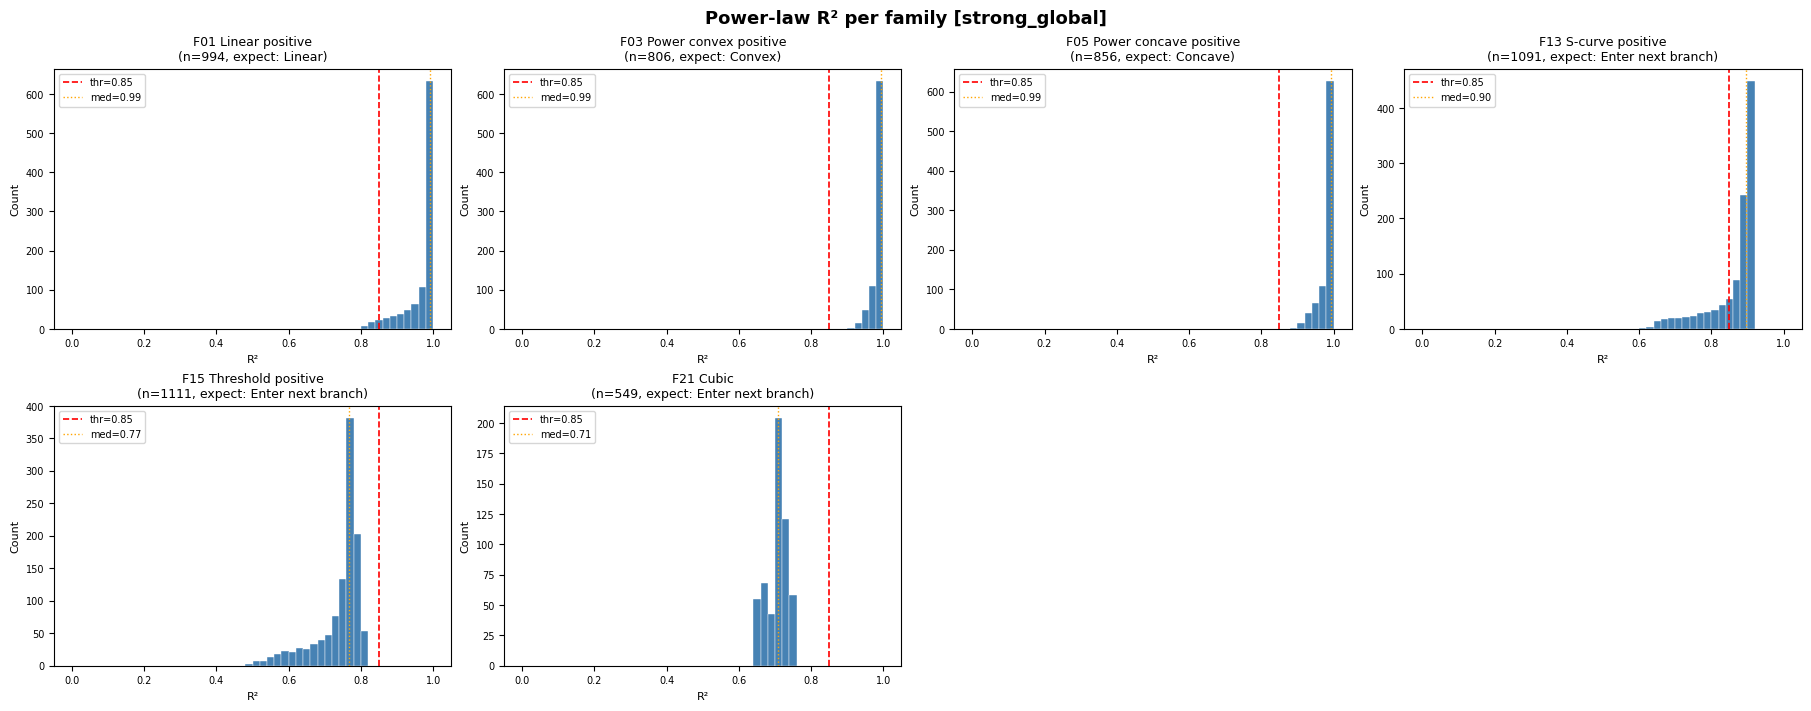

,Family,Expected,n,median R²,mean R²,P10,P25,P75,P90,% >= 0.85
0,F01 Linear positive,Linear,994,0.991,0.968,0.896,0.958,0.996,0.998,96.6%
1,F03 Power convex positive,Convex,806,0.993,0.987,0.964,0.983,0.997,0.999,100.0%
2,F05 Power concave positive,Concave,856,0.992,0.983,0.950,0.978,0.997,0.998,100.0%
3,F13 S-curve positive,Enter next branch,1091,0.896,0.862,0.752,0.847,0.904,0.907,74.2%
4,F15 Threshold positive,Enter next branch,1111,0.767,0.739,0.633,0.724,0.779,0.791,0.0%
5,F21 Cubic,Enter next branch,549,0.708,0.704,0.666,0.682,0.726,0.741,0.0%



=== Power-law R² distribution [intermediate_global] ===


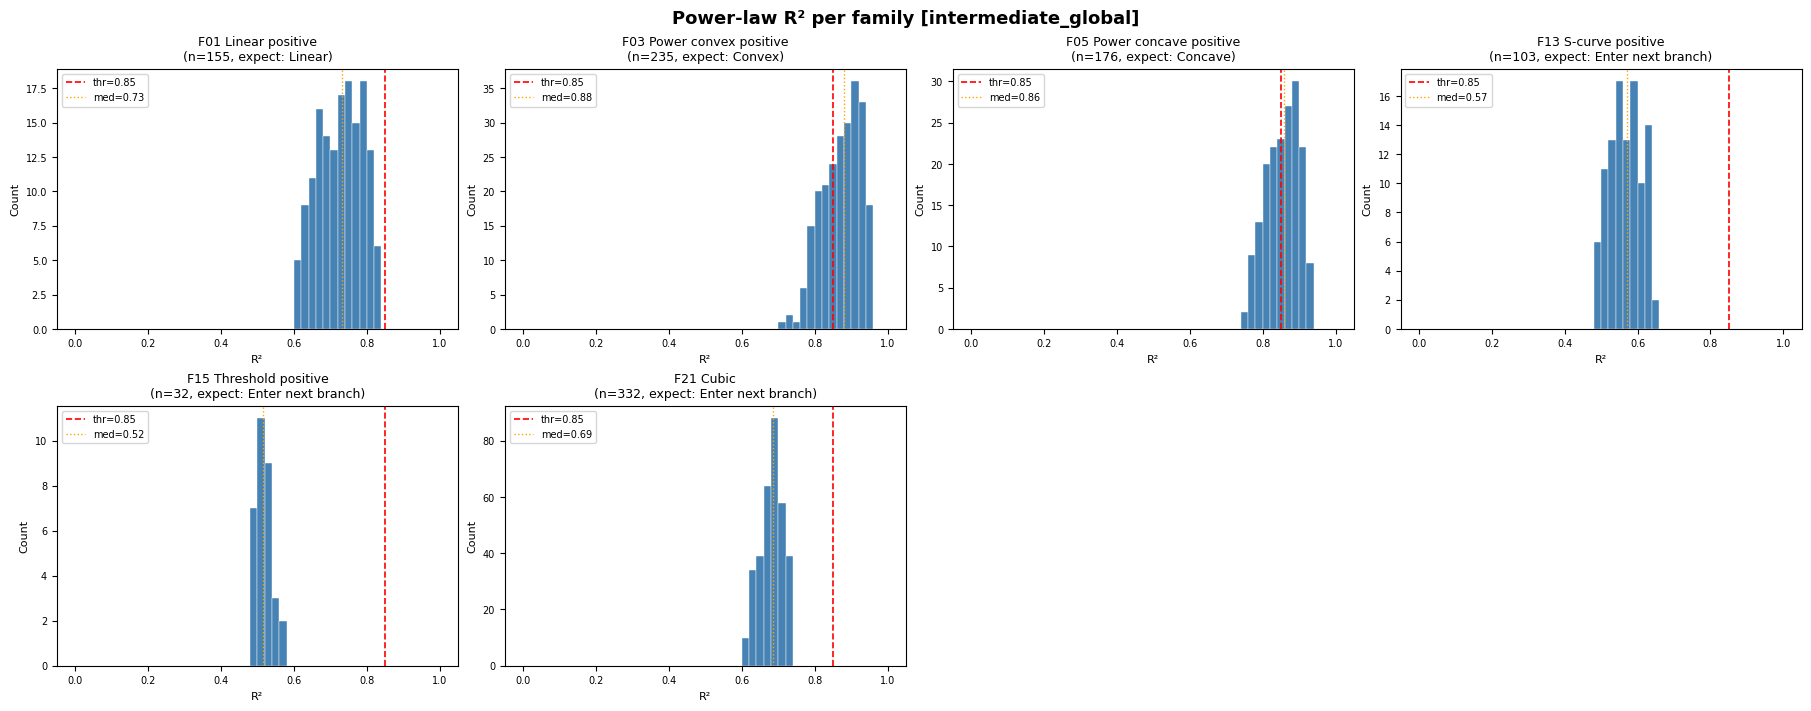

,Family,Expected,n,median R²,mean R²,P10,P25,P75,P90,% >= 0.85
0,F01 Linear positive,Linear,155,0.732,0.727,0.646,0.679,0.777,0.803,0.0%
1,F03 Power convex positive,Convex,235,0.880,0.872,0.799,0.834,0.915,0.936,66.8%
2,F05 Power concave positive,Concave,176,0.860,0.854,0.792,0.820,0.890,0.908,56.2%
3,F13 S-curve positive,Enter next branch,103,0.570,0.568,0.513,0.529,0.601,0.624,0.0%
4,F15 Threshold positive,Enter next branch,32,0.515,0.519,0.493,0.502,0.537,0.550,0.0%
5,F21 Cubic,Enter next branch,332,0.686,0.681,0.636,0.660,0.703,0.722,0.0%


In [437]:
if RUN_SIMPLE_ANALYSIS:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = (data['gate1'] == _gate).values
        _mask_simple_gate = (data['gate2'] == 'Simple').values & _mask_gate
        _simple_data = data.loc[_mask_simple_gate].copy()
        if len(_simple_data) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== Power-law R² distribution [{_gate}] ===')
        print(f'{"="*60}')

        families = sorted(_simple_data['family_id'].unique())
        n_fam = len(families)
        ncols = min(n_fam, 4)
        nrows = math.ceil(n_fam / ncols) if ncols else 1

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows), constrained_layout=True)
        axes = np.array(axes).flatten() if n_fam > 1 else [axes]

        for ax, fid in zip(axes, families):
            r2_vals = _simple_data.loc[_simple_data['family_id'] == fid, 'pw_r2'].dropna()
            fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
            expected = EXPECTED_POWER_ROUTE.get(fid, 'Enter next branch')
            ax.hist(r2_vals, bins=50, range=(0, 1), color='steelblue', edgecolor='white', linewidth=0.3)
            ax.axvline(R2_POWER_THRESHOLD, color='red', ls='--', lw=1.2, label=f'thr={R2_POWER_THRESHOLD}')
            median_r2 = r2_vals.median() if len(r2_vals) > 0 else 0
            ax.axvline(median_r2, color='orange', ls=':', lw=1, label=f'med={median_r2:.2f}')
            ax.set_title(f'{fid} {fname}\n(n={len(r2_vals)}, expect: {expected})', fontsize=9)
            ax.set_xlabel('R²', fontsize=8)
            ax.set_ylabel('Count', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=7)

        for ax in axes[n_fam:]:
            ax.set_visible(False)
        fig.suptitle(f'Power-law R² per family [{_gate}]', fontsize=13, fontweight='bold')
        plt.show()

        # Summary table: percentiles
        rows = []
        for fid in families:
            r2_vals = _simple_data.loc[_simple_data['family_id'] == fid, 'pw_r2'].dropna()
            fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
            expected = EXPECTED_POWER_ROUTE.get(fid, 'Enter next branch')
            pct_above = (r2_vals >= R2_POWER_THRESHOLD).mean() if len(r2_vals) else 0
            rows.append({
                'Family': f'{fid} {fname}',
                'Expected': expected,
                'n': len(r2_vals),
                'median R²': f'{r2_vals.median():.3f}' if len(r2_vals) else 'N/A',
                'mean R²': f'{r2_vals.mean():.3f}' if len(r2_vals) else 'N/A',
                'P10': f'{r2_vals.quantile(0.1):.3f}' if len(r2_vals) else 'N/A',
                'P25': f'{r2_vals.quantile(0.25):.3f}' if len(r2_vals) else 'N/A',
                'P75': f'{r2_vals.quantile(0.75):.3f}' if len(r2_vals) else 'N/A',
                'P90': f'{r2_vals.quantile(0.9):.3f}' if len(r2_vals) else 'N/A',
                f'% >= {R2_POWER_THRESHOLD}': f'{pct_above:.1%}',
            })
        display(pd.DataFrame(rows))

In [438]:
if RUN_SIMPLE_ANALYSIS:
    R2_THRESHOLDS = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98]

    def _route_at_threshold(row, threshold):
        if CLASSIFICATION_ORDER == 'linear_first':
            if not np.isnan(row['pw_b']) and abs(row['pw_b'] - 1) <= LINEAR_B_TOLERANCE:
                return 'Linear'
            if np.isnan(row['pw_r2']) or row['pw_r2'] < threshold:
                return 'Enter next branch'
            curv = row['pw_a'] * row['pw_b'] * (row['pw_b'] - 1)
            return 'Concave' if curv < 0 else 'Convex'
        else:
            if np.isnan(row['pw_r2']) or row['pw_r2'] < threshold:
                return 'Enter next branch'
            b = row['pw_b']
            a = row['pw_a']
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return 'Linear'
            curv = a * b * (b - 1)
            return 'Concave' if curv < 0 else 'Convex'

    for _gate in MIC_ANALYSIS_GATES:
        _mask_gate = (data['gate1'] == _gate).values
        _mask_simple_gate = (data['gate2'] == 'Simple').values & _mask_gate
        _simple_data = data.loc[_mask_simple_gate].copy()
        if len(_simple_data) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== R² threshold sweep [{_gate}] (mode={CLASSIFICATION_ORDER}) ===')
        print(f'{"="*60}')

        rows = []
        for thr in R2_THRESHOLDS:
            _simple_data['_route'] = _simple_data.apply(lambda r: _route_at_threshold(r, thr), axis=1)
            _simple_data['_expected'] = _simple_data['family_id'].map(EXPECTED_POWER_ROUTE).fillna('Enter next branch')
            _simple_data['_correct'] = _simple_data['_route'] == _simple_data['_expected']

            per_family = _simple_data.groupby('family_id').agg(
                total=('case_id', 'size'),
                correct=('_correct', 'sum'),
            )

            row_data = {'R² threshold': thr}
            for fid in sorted(per_family.index):
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
                n_correct = int(per_family.loc[fid, 'correct'])
                n_total = int(per_family.loc[fid, 'total'])
                row_data[fname] = f'{n_correct}/{n_total} ({n_correct/n_total:.1%})'
            overall_correct = int(per_family['correct'].sum())
            overall_total = int(per_family['total'].sum())
            row_data['Overall'] = f'{overall_correct}/{overall_total} ({overall_correct/overall_total:.1%})'
            rows.append(row_data)

        sweep_df = pd.DataFrame(rows).set_index('R² threshold')
        display(sweep_df.T)


=== R² threshold sweep [strong_global] (mode=r2_first) ===


R² threshold,0.70,0.75,0.80,0.85,0.90,0.95,0.98
Linear positive,962/994 (96.8%),962/994 (96.8%),962/994 (96.8%),936/994 (94.2%),874/994 (87.9%),771/994 (77.6%),632/994 (63.6%)
Power convex positive,806/806 (100.0%),806/806 (100.0%),806/806 (100.0%),806/806 (100.0%),806/806 (100.0%),773/806 (95.9%),632/806 (78.4%)
Power concave positive,856/856 (100.0%),856/856 (100.0%),856/856 (100.0%),856/856 (100.0%),855/856 (99.9%),771/856 (90.1%),626/856 (73.1%)
S-curve positive,56/1091 (5.1%),109/1091 (10.0%),178/1091 (16.3%),282/1091 (25.8%),643/1091 (58.9%),1091/1091 (100.0%),1091/1091 (100.0%)
Threshold positive,217/1111 (19.5%),416/1111 (37.4%),1058/1111 (95.2%),1111/1111 (100.0%),1111/1111 (100.0%),1111/1111 (100.0%),1111/1111 (100.0%)
Cubic,166/549 (30.2%),549/549 (100.0%),549/549 (100.0%),549/549 (100.0%),549/549 (100.0%),549/549 (100.0%),549/549 (100.0%)
Overall,3063/5407 (56.6%),3698/5407 (68.4%),4409/5407 (81.5%),4540/5407 (84.0%),4838/5407 (89.5%),5066/5407 (93.7%),4641/5407 (85.8%)



=== R² threshold sweep [intermediate_global] (mode=r2_first) ===


R² threshold,0.70,0.75,0.80,0.85,0.90,0.95,0.98
Linear positive,72/155 (46.5%),45/155 (29.0%),15/155 (9.7%),0/155 (0.0%),0/155 (0.0%),0/155 (0.0%),0/155 (0.0%)
Power convex positive,235/235 (100.0%),231/235 (98.3%),210/235 (89.4%),157/235 (66.8%),87/235 (37.0%),5/235 (2.1%),0/235 (0.0%)
Power concave positive,176/176 (100.0%),175/176 (99.4%),152/176 (86.4%),99/176 (56.2%),30/176 (17.0%),0/176 (0.0%),0/176 (0.0%)
S-curve positive,103/103 (100.0%),103/103 (100.0%),103/103 (100.0%),103/103 (100.0%),103/103 (100.0%),103/103 (100.0%),103/103 (100.0%)
Threshold positive,32/32 (100.0%),32/32 (100.0%),32/32 (100.0%),32/32 (100.0%),32/32 (100.0%),32/32 (100.0%),32/32 (100.0%)
Cubic,235/332 (70.8%),332/332 (100.0%),332/332 (100.0%),332/332 (100.0%),332/332 (100.0%),332/332 (100.0%),332/332 (100.0%)
Overall,853/1033 (82.6%),918/1033 (88.9%),844/1033 (81.7%),723/1033 (70.0%),584/1033 (56.5%),472/1033 (45.7%),467/1033 (45.2%)


In [439]:
# ── KL/QR/HD diagnostic for Simple-path R²-fail pool ──
from scipy.stats import gaussian_kde
try:
    from diptest import diptest as diptest_func
except ImportError:
    diptest_func = None
    print('WARNING: diptest not installed, HD test will be skipped')

def _cond_density_inline(x, y, n_grid_x=30, n_grid_y=50):
    if KL_METHOD == 'kde':
        gx = np.linspace(x.min(), x.max(), n_grid_x)
        gy = np.linspace(y.min(), y.max(), n_grid_y)
        GX, GY = np.meshgrid(gx, gy, indexing='ij')
        grid_pts = np.vstack([GX.ravel(), GY.ravel()])
        try:
            kde2d = gaussian_kde(np.vstack([x, y]), bw_method='silverman')
            density_2d = kde2d(grid_pts).reshape(n_grid_x, n_grid_y)
        except np.linalg.LinAlgError:
            return None
        kde_x = gaussian_kde(x, bw_method='silverman')
        p_x = kde_x(gx)
        p_x = p_x / p_x.sum()
        p_cond = np.zeros_like(density_2d)
        for ix in range(n_grid_x):
            col_sum = density_2d[ix].sum()
            if col_sum > 1e-20:
                p_cond[ix] = density_2d[ix] / col_sum
            else:
                p_cond[ix] = 1.0 / n_grid_y
        kde_y = gaussian_kde(y, bw_method='silverman')
        p_marginal_y = kde_y(gy)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()
        return gx, gy, p_cond, p_marginal_y, p_x
    else:
        hist2d, xedges, yedges = np.histogram2d(x, y, bins=[n_grid_x, n_grid_y])
        gx = 0.5 * (xedges[:-1] + xedges[1:])
        gy = 0.5 * (yedges[:-1] + yedges[1:])
        hist2d = hist2d + 1e-10
        p_x = hist2d.sum(axis=1)
        p_x = p_x / p_x.sum()
        p_cond = hist2d / hist2d.sum(axis=1, keepdims=True)
        p_marginal_y = hist2d.sum(axis=0)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()
        return gx, gy, p_cond, p_marginal_y, p_x

def _kl_inline(p_cond, p_marginal_y, p_x):
    kl = 0.0
    for ix in range(p_cond.shape[0]):
        pc = np.maximum(p_cond[ix], 1e-20)
        pm = np.maximum(p_marginal_y, 1e-20)
        kl += p_x[ix] * np.sum(pc * np.log(pc / pm))
    return float(kl)

def _qr_inline(p_cond, gy):
    iqrs = []
    for ix in range(p_cond.shape[0]):
        cdf = np.cumsum(p_cond[ix])
        cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
        q05 = gy[np.searchsorted(cdf, 0.05)]
        q95 = gy[np.searchsorted(cdf, 0.95, side='right').clip(max=len(gy)-1)]
        iqrs.append(q95 - q05)
    iqrs = np.array(iqrs)
    q01_iqr = np.percentile(iqrs, 1)
    q99_iqr = np.percentile(iqrs, 99)
    if q01_iqr < 1e-10:
        return np.nan
    return float(q99_iqr / q01_iqr)

def _klqr_inline(x, y, n_perm=99):
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 20:
        return np.nan, np.nan, np.nan, np.nan
    result = _cond_density_inline(x, y)
    if result is None:
        return np.nan, np.nan, np.nan, np.nan
    gx, gy, p_cond, p_marginal_y, p_x = result
    kl_obs = _kl_inline(p_cond, p_marginal_y, p_x)
    qr_obs = _qr_inline(p_cond, gy)
    kl_count = 0
    qr_count = 0
    rng = np.random.RandomState(42)
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        res_perm = _cond_density_inline(x, y_perm)
        if res_perm is None:
            continue
        _, gy_p, pc_p, pm_p, px_p = res_perm
        if _kl_inline(pc_p, pm_p, px_p) >= kl_obs:
            kl_count += 1
        qr_perm = _qr_inline(pc_p, gy_p)
        if not np.isnan(qr_perm) and not np.isnan(qr_obs) and qr_perm >= qr_obs:
            qr_count += 1
    kl_p = float((kl_count + 1) / (n_perm + 1))
    qr_p = float((qr_count + 1) / (n_perm + 1)) if not np.isnan(qr_obs) else np.nan
    return kl_obs, kl_p, qr_obs, qr_p

def _hd_inline(y):
    valid = np.isfinite(y)
    y = y[valid]
    if len(y) < 10 or diptest_func is None:
        return np.nan, np.nan
    stat, p = diptest_func(y)
    return float(stat), float(p)

for _gate in MIC_ANALYSIS_GATES:
    r2_fail_data = data[(data['pw_label'] == 'r2_fail') & (data['gate2'] == 'Simple') & (data['gate1'] == _gate)].copy()
    n_r2_fail = len(r2_fail_data)
    print(f'\n{"="*60}')
    print(f'=== KL/QR/HD: Simple R2-fail [{_gate}] ({n_r2_fail} cases, {KL_METHOD}) ===')
    print(f'{"="*60}')

    if n_r2_fail > 0:
        r2fail_results = []
        for idx, row in tqdm(r2_fail_data.iterrows(), total=n_r2_fail, desc=f'KL/QR/HD R2-fail [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)
            kl_stat, kl_p, qr_stat, qr_p = _klqr_inline(x, y)
            hd_stat, hd_p = _hd_inline(y)
            r2fail_results.append({
                'case_id': row['case_id'], 'family_id': row['family_id'],
                'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
                'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
                'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
            })

        r2fail_df = pd.DataFrame(r2fail_results)
        r2fail_df['family_name'] = r2fail_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        print('Significance rates per family:')
        _rf_summary = r2fail_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            KL_mean=('kl_stat', 'mean'),
            KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
            QR_mean=('qr_stat', 'mean'),
            QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
            HD_mean=('hd_stat', 'mean'),
            HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
        ).round(4)
        display(_rf_summary)
    else:
        print('No R2-fail cases.')


=== KL/QR/HD: Simple R2-fail [strong_global] (1976 cases, histogram) ===


KL/QR/HD R2-fail [strong_global]: 100%|██████████| 1976/1976 [01:27<00:00, 22.59it/s]

Significance rates per family:


,,n,KL_mean,KL_sig,QR_mean,QR_sig,HD_mean,HD_sig
family_id,family_name,,,,,,,
F01,Linear positive,34,1.4382,34 (100.0%),2.6787,26 (76.5%),0.0142,0 (0.0%)
F13,S-curve positive,282,1.3990,282 (100.0%),2.5756,238 (84.4%),0.0462,252 (89.4%)
F15,Threshold positive,1111,1.1170,"1,111 (100.0%)",5.5085,"1,035 (93.2%)",0.1468,"1,078 (97.0%)"
F21,Cubic,549,1.9690,549 (100.0%),6.0574,85 (15.5%),0.0157,65 (11.8%)



=== KL/QR/HD: Simple R2-fail [intermediate_global] (777 cases, histogram) ===


KL/QR/HD R2-fail [intermediate_global]: 100%|██████████| 777/777 [00:33<00:00, 22.88it/s]

Significance rates per family:


,,n,KL_mean,KL_sig,QR_mean,QR_sig,HD_mean,HD_sig
family_id,family_name,,,,,,,
F01,Linear positive,155,1.3193,155 (100.0%),2.6296,75 (48.4%),0.0129,0 (0.0%)
F03,Power convex positive,78,1.2565,78 (100.0%),2.5321,0 (0.0%),0.0099,0 (0.0%)
F05,Power concave positive,77,1.2200,77 (100.0%),2.5900,0 (0.0%),0.0104,0 (0.0%)
F13,S-curve positive,103,1.2287,103 (100.0%),2.5836,51 (49.5%),0.0145,1 (1.0%)
F15,Threshold positive,32,1.2733,32 (100.0%),2.2317,6 (18.8%),0.0168,0 (0.0%)
F21,Cubic,332,1.5197,332 (100.0%),2.7342,0 (0.0%),0.0096,0 (0.0%)


## Method A — Local-linear derivative with multiscale turning-point consensus

At each bandwidth, compute the local-linear derivative β₁(x, h) directly (no SE, no significance test).
Count stable turning points (sign changes of β₁) across multiple bandwidths.

- **Bandwidth range**: geomspace(0.04, 0.18, 5) on x ∈ [0, 1]
- **Interior only**: x ∈ [0.05, 0.95] to avoid boundary bias
- **Short-segment filter**: sign runs < 5% of grid are ignored (noise)
- **P_2TP**: fraction of bandwidths with exactly 2 TPs
- **TP stability**: check TP positions are consistent across bandwidths

In [440]:
if RUN_METHOD_A:
    # ── Local-linear derivative with multiscale TP consensus ──
    
    
    def multiscale_tp_analysis(x, y, n_bandwidths=5, n_grid=200,
                               h_min=0.04, h_max=0.18,
                               interior=(0.05, 0.95),
                               min_run_frac=0.05,
                               flat_frac=FLAT_FRAC):
        """Compute local-linear derivative at multiple bandwidths, count turning points.
        
        Also computes width_ratio: fraction of interior with |β₁| > eps.
        """
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 20:
            return None
        
        x_min, x_max = x.min(), x.max()
        x_range = x_max - x_min
        if x_range < 1e-10:
            return None
        x_norm = (x - x_min) / x_range
        
        x_grid = np.linspace(0, 1, n_grid)
        bandwidths = np.geomspace(h_min, h_max, n_bandwidths)
        
        interior_mask = (x_grid >= interior[0]) & (x_grid <= interior[1])
        n_interior = interior_mask.sum()
        min_run_len = max(int(min_run_frac * n_interior), 3)
        
        per_bw = []
        deriv_matrix = np.zeros((n_bandwidths, n_grid))
        
        for bw_idx, h in enumerate(bandwidths):
            beta1_row = np.full(n_grid, np.nan)
            
            for gi, xg in enumerate(x_grid):
                w = np.exp(-0.5 * ((x_norm - xg) / h) ** 2)
                w_sum = w.sum()
                if w_sum < 1e-10:
                    continue
                
                dx = x_norm - xg
                s0 = w_sum
                s1 = (w * dx).sum()
                s2 = (w * dx ** 2).sum()
                denom = s0 * s2 - s1 ** 2
                if abs(denom) < 1e-20:
                    continue
                
                beta1 = (s0 * (w * dx * y).sum() - s1 * (w * y).sum()) / denom
                beta1_row[gi] = beta1
            
            deriv_matrix[bw_idx] = beta1_row
            
            interior_deriv = beta1_row[interior_mask]
            if np.any(np.isfinite(interior_deriv)):
                abs_deriv = np.abs(interior_deriv)
                ref_val = np.nanmax(abs_deriv) if FLAT_REF == 'max' else np.nanmedian(abs_deriv)
                eps = flat_frac * ref_val
            else:
                eps = 0.0
            
            # TP count
            tp_count, tp_positions = _count_stable_tps(
                interior_deriv, x_grid[interior_mask], min_run_len, eps
            )
            
            # Width ratio: fraction of interior with |β₁| > eps
            n_significant = np.sum(np.abs(interior_deriv) > eps)
            width_ratio = float(n_significant / n_interior) if n_interior > 0 else 0.0
            
            per_bw.append({
                'bw_index': bw_idx + 1,
                'bandwidth': float(h),
                'tp_count': int(tp_count),
                'tp_positions': tp_positions,
                'width_ratio': width_ratio,
            })
        
        n_2tp = sum(1 for bw in per_bw if bw['tp_count'] == 2)
        tp_stable = _check_tp_stability(per_bw)
        
        return {
            'per_bw': per_bw,
            'p_2tp': n_2tp / n_bandwidths,
            'n_2tp_bw': n_2tp,
            'n_bandwidths': n_bandwidths,
            'tp_stable': tp_stable,
            'deriv_matrix': deriv_matrix,
            'x_grid': x_grid,
        }
    
    
    def _count_stable_tps(deriv, x_positions, min_run_len, eps=0.0):
        """Count turning points from stable sign runs in the derivative."""
        n = len(deriv)
        if n < 2:
            return 0, []
        
        runs = []
        current_sign = 0
        current_start = 0
        
        for i in range(n):
            if np.isnan(deriv[i]) or abs(deriv[i]) < eps:
                if current_sign != 0 and (i - current_start) >= min_run_len:
                    runs.append((current_sign, current_start, i - 1))
                current_sign = 0
                continue
            
            s = 1 if deriv[i] > 0 else -1
            if s != current_sign:
                if current_sign != 0 and (i - current_start) >= min_run_len:
                    runs.append((current_sign, current_start, i - 1))
                current_sign = s
                current_start = i
        
        if current_sign != 0 and (n - current_start) >= min_run_len:
            runs.append((current_sign, current_start, n - 1))
        
        tp_count = 0
        tp_positions = []
        for i in range(1, len(runs)):
            if runs[i][0] != runs[i - 1][0]:
                tp_count += 1
                idx_mid = (runs[i - 1][2] + runs[i][1]) // 2
                if idx_mid < len(x_positions):
                    tp_positions.append(float(x_positions[idx_mid]))
        
        return tp_count, tp_positions
    
    
    def _check_tp_stability(per_bw):
        """Check if TP positions are stable across bandwidths that have 2 TPs."""
        bws_with_2tp = [bw for bw in per_bw if bw['tp_count'] == 2]
        if len(bws_with_2tp) < 2:
            return len(bws_with_2tp) == 1
        
        tp1_positions = [bw['tp_positions'][0] for bw in bws_with_2tp]
        tp2_positions = [bw['tp_positions'][1] for bw in bws_with_2tp]
        
        tp1_range = max(tp1_positions) - min(tp1_positions)
        tp2_range = max(tp2_positions) - min(tp2_positions)
        
        return tp1_range < 0.15 and tp2_range < 0.15
    
    print(f'Multiscale TP helpers defined.  FLAT_FRAC = {FLAT_FRAC}, FLAT_REF = {FLAT_REF!r}')

Multiscale TP helpers defined.  FLAT_FRAC = 0.05, FLAT_REF = 'max'


In [441]:
if RUN_METHOD_A:
    sizer_dfs = {}
    sizer_bw_dfs = {}

    for _gate in MIC_ANALYSIS_GATES:
        complex_data = complex_datas.get(_gate)
        if complex_data is None or len(complex_data) == 0:
            print(f'[{_gate}] No complex cases, skipping Method A.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Multiscale TP [{_gate}] — {len(complex_data):,} cases ===')
        print(f'{"="*60}')

        sizer_results = []
        sizer_per_bw_records = []

        t0 = time.time()
        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'Multiscale TP [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)
            result = multiscale_tp_analysis(x, y)

            cid = row['case_id']
            fid = row['family_id']

            if result is not None:
                tp_counts = [bw['tp_count'] for bw in result['per_bw']]
                w_ratios = [bw['width_ratio'] for bw in result['per_bw']]
                sizer_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_0tp_bw': sum(1 for t in tp_counts if t == 0),
                    'n_1tp_bw': sum(1 for t in tp_counts if t == 1),
                    'n_2tp_bw': sum(1 for t in tp_counts if t == 2),
                    'n_3tp_bw': sum(1 for t in tp_counts if t == 3),
                    'n_gt3tp_bw': sum(1 for t in tp_counts if t > 3),
                    'tp_stable': result['tp_stable'],
                    'width_ratio_fine': w_ratios[0],
                    'width_ratio_mean': float(np.mean(w_ratios)),
                })
                for bw_info in result['per_bw']:
                    sizer_per_bw_records.append({
                        'case_id': cid, 'family_id': fid,
                        'bw_index': bw_info['bw_index'],
                        'bandwidth': bw_info['bandwidth'],
                        'tp_count': bw_info['tp_count'],
                        'width_ratio': bw_info['width_ratio'],
                        'tp_positions': bw_info['tp_positions'],
                    })
            else:
                sizer_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_0tp_bw': 0, 'n_1tp_bw': 0, 'n_2tp_bw': 0,
                    'n_3tp_bw': 0, 'n_gt3tp_bw': 0, 'tp_stable': False,
                    'width_ratio_fine': np.nan, 'width_ratio_mean': np.nan,
                })

        print(f'Multiscale TP: {len(sizer_results):,} cases in {time.time()-t0:.1f}s')

        sizer_df = pd.DataFrame(sizer_results)
        sizer_df['family_name'] = sizer_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        sizer_bw_df = pd.DataFrame(sizer_per_bw_records)

        sizer_dfs[_gate] = sizer_df
        sizer_bw_dfs[_gate] = sizer_bw_df

        print(f'\nSummary per family (mean # bandwidths supporting each TP count):')
        display(sizer_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            tp0=('n_0tp_bw', 'mean'),
            tp1=('n_1tp_bw', 'mean'),
            tp2=('n_2tp_bw', 'mean'),
            tp3=('n_3tp_bw', 'mean'),
            tp_gt3=('n_gt3tp_bw', 'mean'),
            wr_fine=('width_ratio_fine', 'mean'),
            wr_mean=('width_ratio_mean', 'mean'),
        ).round(2))


=== Multiscale TP [strong_global] — 4,026 cases ===


Multiscale TP [strong_global]:   0%|          | 0/4026 [00:00<?, ?it/s]

Multiscale TP [strong_global]: 100%|██████████| 4026/4026 [00:45<00:00, 88.13it/s]

Multiscale TP: 4,026 cases in 45.7s

Summary per family (mean # bandwidths supporting each TP count):


,,n,tp0,tp1,tp2,tp3,tp_gt3,wr_fine,wr_mean
family_id,family_name,,,,,,,,
F01,Linear positive,34,5.00,0.00,0.00,0.00,0.00,1.00,1.00
F07,Saturation positive,55,5.00,0.00,0.00,0.00,0.00,0.25,0.36
F13,S-curve positive,282,4.17,0.40,0.15,0.06,0.22,0.80,0.87
F15,Threshold positive,1112,4.49,0.39,0.06,0.04,0.02,0.29,0.58
F18,Quadratic valley (U),916,0.00,5.00,0.00,0.00,0.00,0.95,0.96
F21,Cubic,549,1.39,0.00,3.61,0.00,0.00,0.86,0.88
F22,Oscillation,987,0.81,0.00,1.14,0.00,3.04,0.97,0.87
F23,Two Lines,71,3.94,0.00,0.75,0.00,0.31,0.93,0.98
F25,Multi-regime threshold,10,1.30,0.00,2.20,0.00,1.50,0.75,0.70



=== Multiscale TP [intermediate_global] — 2,411 cases ===


Multiscale TP [intermediate_global]: 100%|██████████| 2411/2411 [00:27<00:00, 87.52it/s]


Multiscale TP: 2,411 cases in 27.5s

Summary per family (mean # bandwidths supporting each TP count):


,,n,tp0,tp1,tp2,tp3,tp_gt3,wr_fine,wr_mean
family_id,family_name,,,,,,,,
F01,Linear positive,155,4.88,0.02,0.10,0.00,0.00,0.99,1.00
F03,Power convex positive,78,3.23,1.19,0.58,0.00,0.00,0.81,0.81
F05,Power concave positive,77,5.00,0.00,0.00,0.00,0.00,0.91,0.98
F07,Saturation positive,582,5.00,0.00,0.00,0.00,0.00,0.25,0.36
F13,S-curve positive,114,3.03,0.86,0.15,0.43,0.54,0.87,0.89
F15,Threshold positive,99,1.99,1.67,0.16,0.89,0.29,0.68,0.80
F18,Quadratic valley (U),173,0.00,5.00,0.00,0.00,0.00,0.95,0.96
F21,Cubic,332,1.37,0.00,3.63,0.00,0.00,0.85,0.88
F22,Oscillation,153,0.82,0.00,1.18,0.00,3.00,0.97,0.88



=== TP support diagnostic [strong_global] ===

=== Per-bandwidth mean TP count by family ===


,family_name,bw_1,bw_2,bw_3,bw_4,bw_5
family_id,,,,,,
F01,Linear positive,0.00,0.00,0.00,0.00,0.00
F07,Saturation positive,0.00,0.00,0.00,0.00,0.00
F13,S-curve positive,1.53,0.22,0.01,0.00,0.00
F15,Threshold positive,0.40,0.21,0.10,0.02,0.00
F18,Quadratic valley (U),1.00,1.00,1.00,1.00,1.00
F21,Cubic,2.00,2.00,2.00,1.23,0.00
F22,Oscillation,6.00,6.00,6.00,1.64,0.82
F23,Two Lines,2.07,0.76,0.00,0.00,0.00
F25,Multi-regime threshold,5.80,3.20,1.80,1.60,0.00



=== TP = 0 support distribution — Monotonic (S/Threshold/Saturation…) ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,34,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),34 (100.0%)
F07,Saturation positive,55,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),55 (100.0%)
F13,S-curve positive,282,0 (0.0%),0 (0.0%),4 (1.4%),44 (15.6%),134 (47.5%),100 (35.5%)
F15,Threshold positive,1112,0 (0.0%),13 (1.2%),87 (7.8%),91 (8.2%),76 (6.8%),845 (76.0%)
F18,Quadratic valley (U),916,916 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,549,0 (0.0%),337 (61.4%),212 (38.6%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,987,405 (41.0%),362 (36.7%),220 (22.3%),0 (0.0%),0 (0.0%),0 (0.0%)
F23,Two Lines,71,0 (0.0%),0 (0.0%),0 (0.0%),27 (38.0%),21 (29.6%),23 (32.4%)
F25,Multi-regime threshold,10,0 (0.0%),8 (80.0%),1 (10.0%),1 (10.0%),0 (0.0%),0 (0.0%)



=== TP = 1 support distribution — U-shape / Spike (F18/F19/F20) ===


...

,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,34,34 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,282,241 (85.5%),41 (14.5%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,1112,"1,052 (94.6%)",48 (4.3%),12 (1.1%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),916,916 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,549,0 (0.0%),0 (0.0%),0 (0.0%),212 (38.6%),337 (61.4%),0 (0.0%)
F22,Oscillation,987,220 (22.3%),406 (41.1%),361 (36.6%),0 (0.0%),0 (0.0%),0 (0.0%)
F23,Two Lines,71,30 (42.3%),29 (40.8%),12 (16.9%),0 (0.0%),0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,10,1 (10.0%),1 (10.0%),3 (30.0%),5 (50.0%),0 (0.0%),0 (0.0%)



=== TP = 3 support distribution — Oscillation / Multi-regime ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,34,34 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,282,265 (94.0%),17 (6.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,1112,"1,069 (96.1%)",40 (3.6%),3 (0.3%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),916,916 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,549,549 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,987,987 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F23,Two Lines,71,71 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,10,10 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP > 3 support distribution — High-frequency oscillation ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,34,34 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,282,223 (79.1%),55 (19.5%),4 (1.4%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,1112,"1,090 (98.0%)",22 (2.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),916,916 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,549,549 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,987,0 (0.0%),0 (0.0%),0 (0.0%),943 (95.5%),44 (4.5%),0 (0.0%)
F23,Two Lines,71,49 (69.0%),22 (31.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F25,Multi-regime threshold,10,0 (0.0%),5 (50.0%),5 (50.0%),0 (0.0%),0 (0.0%),0 (0.0%)


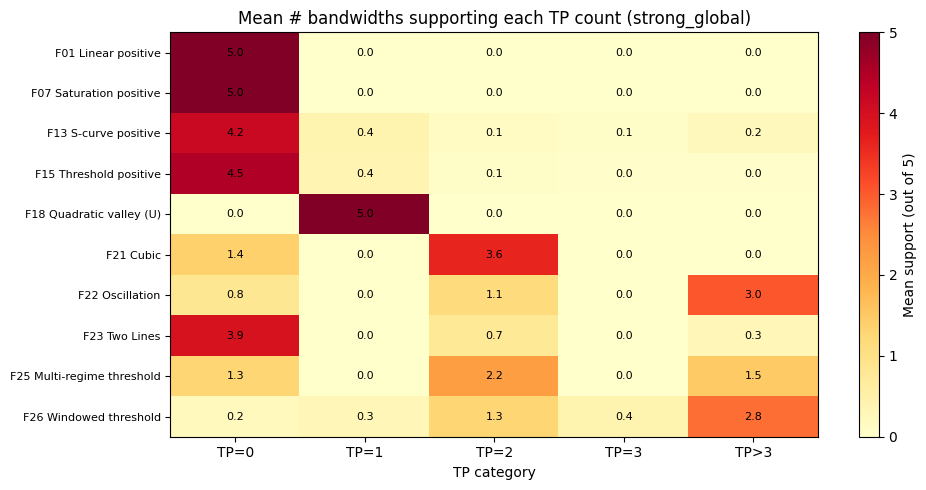


=== TP support diagnostic [intermediate_global] ===

=== Per-bandwidth mean TP count by family ===


,family_name,bw_1,bw_2,bw_3,bw_4,bw_5
family_id,,,,,,
F01,Linear positive,0.21,0.00,0.00,0.00,0.00
F03,Power convex positive,1.24,0.72,0.26,0.13,0.00
F05,Power concave positive,0.00,0.00,0.00,0.00,0.00
F07,Saturation positive,0.00,0.00,0.00,0.00,0.00
F13,S-curve positive,3.15,1.16,0.26,0.05,0.00
F15,Threshold positive,2.94,1.63,0.94,0.44,0.00
F18,Quadratic valley (U),1.00,1.00,1.00,1.00,1.00
F21,Cubic,2.00,2.00,2.00,1.25,0.00
F22,Oscillation,6.00,6.00,6.00,1.50,0.86



=== TP = 0 support distribution — Monotonic (S/Threshold/Saturation…) ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),18 (11.6%),137 (88.4%)
F03,Power convex positive,78,0 (0.0%),10 (12.8%),10 (12.8%),25 (32.1%),18 (23.1%),15 (19.2%)
F05,Power concave positive,77,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77 (100.0%)
F07,Saturation positive,582,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),582 (100.0%)
F13,S-curve positive,114,0 (0.0%),6 (5.3%),24 (21.1%),45 (39.5%),39 (34.2%),0 (0.0%)
F15,Threshold positive,99,0 (0.0%),41 (41.4%),33 (33.3%),10 (10.1%),15 (15.2%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,0 (0.0%),208 (62.7%),124 (37.3%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,66 (43.1%),49 (32.0%),38 (24.8%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 1 support distribution — U-shape / Spike (F18/F19/F20) ===


...

,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,140 (90.3%),15 (9.7%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,44 (56.4%),23 (29.5%),11 (14.1%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,97 (85.1%),17 (14.9%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,86 (86.9%),10 (10.1%),3 (3.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,0 (0.0%),0 (0.0%),0 (0.0%),124 (37.3%),208 (62.7%),0 (0.0%)
F22,Oscillation,153,38 (24.8%),49 (32.0%),66 (43.1%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP = 3 support distribution — Oscillation / Multi-regime ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,67 (58.8%),45 (39.5%),2 (1.8%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,30 (30.3%),59 (59.6%),1 (1.0%),9 (9.1%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,153 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



=== TP > 3 support distribution — High-frequency oscillation ===


,family_name,n,0/5,1/5,2/5,3/5,4/5,5/5
family_id,,,,,,,,
F01,Linear positive,155,155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,114,65 (57.0%),37 (32.5%),12 (10.5%),0 (0.0%),0 (0.0%),0 (0.0%)
F15,Threshold positive,99,70 (70.7%),29 (29.3%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,0 (0.0%),0 (0.0%),0 (0.0%),153 (100.0%),0 (0.0%),0 (0.0%)


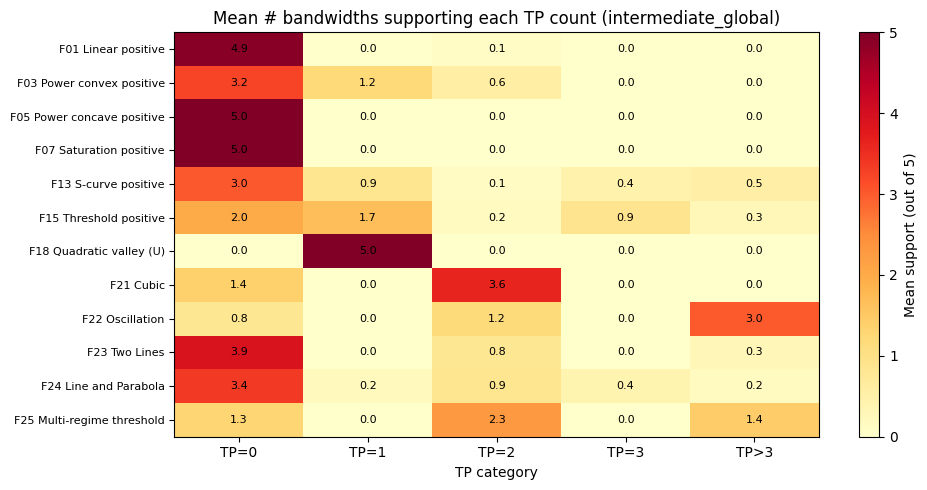

In [442]:
if RUN_METHOD_A:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        sizer_bw_df = sizer_bw_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== TP support diagnostic [{_gate}] ===')
        print(f'{"="*60}')

        print('\n=== Per-bandwidth mean TP count by family ===')
        if len(sizer_bw_df) > 0:
            _bw_tp = sizer_bw_df.pivot_table(
                index='family_id', columns='bw_index', values='tp_count', aggfunc='mean'
            ).round(2)
            _bw_tp.columns = [f'bw_{int(c)}' for c in _bw_tp.columns]
            _bw_tp.insert(0, 'family_name', _bw_tp.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
            display(_bw_tp)

        TP_CATEGORIES = [
            ('n_0tp_bw', 'TP = 0', 'Monotonic (S/Threshold/Saturation…)'),
            ('n_1tp_bw', 'TP = 1', 'U-shape / Spike (F18/F19/F20)'),
            ('n_2tp_bw', 'TP = 2', 'Cubic (F21)'),
            ('n_3tp_bw', 'TP = 3', 'Oscillation / Multi-regime'),
            ('n_gt3tp_bw', 'TP > 3', 'High-frequency oscillation'),
        ]

        for col, tp_label, description in TP_CATEGORIES:
            print(f'\n=== {tp_label} support distribution — {description} ===')
            _support = sizer_df.copy()
            _support[col] = _support[col].fillna(0).astype(int)
            _sup_table = _support.groupby('family_id')[col].value_counts().unstack(fill_value=0)
            _sup_table = _sup_table.reindex(columns=range(6), fill_value=0)
            _sup_totals = _sup_table.sum(axis=1)
            _sup_out = pd.DataFrame(index=_sup_table.index)
            _sup_out['family_name'] = _sup_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _sup_out['n'] = _sup_totals
            for c in _sup_table.columns:
                _sup_out[f'{c}/5'] = [count_percent(int(n), int(t)) for n, t in zip(_sup_table[c], _sup_totals)]
            display(_sup_out)

        fig, ax = plt.subplots(figsize=(10, 5))
        tp_cols = ['n_0tp_bw', 'n_1tp_bw', 'n_2tp_bw', 'n_3tp_bw', 'n_gt3tp_bw']
        tp_labels = ['TP=0', 'TP=1', 'TP=2', 'TP=3', 'TP>3']
        _heat = sizer_df.groupby('family_id')[tp_cols].mean()
        _heat.columns = tp_labels
        _heat = _heat.loc[sorted(_heat.index)]

        im = ax.imshow(_heat.values, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(len(tp_labels)))
        ax.set_xticklabels(tp_labels)
        ax.set_yticks(range(len(_heat.index)))
        fnames = [f'{fid} {FAMILY_CATALOGUE.get(fid, {}).get("name", "")}' for fid in _heat.index]
        ax.set_yticklabels(fnames, fontsize=8)
        for i in range(len(_heat.index)):
            for j in range(len(tp_labels)):
                ax.text(j, i, f'{_heat.values[i, j]:.1f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'Mean # bandwidths supporting each TP count ({_gate})')
        ax.set_xlabel('TP category')
        fig.colorbar(im, ax=ax, label='Mean support (out of 5)')
        plt.tight_layout()
        plt.show()


=== Width Ratio Distribution [strong_global] ===
width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean,wr_mean_std
family_id,family_name,,,,,,,
F01,Linear positive,34,0.998,0.006,0.978,1.000,1.000,0.001
F07,Saturation positive,55,0.247,0.006,0.239,0.256,0.360,0.005
F13,S-curve positive,282,0.797,0.069,0.611,0.933,0.873,0.037
F15,Threshold positive,1112,0.292,0.123,0.200,0.750,0.582,0.071
F18,Quadratic valley (U),916,0.953,0.012,0.894,0.978,0.958,0.004
F21,Cubic,549,0.861,0.017,0.822,0.906,0.880,0.009
F22,Oscillation,987,0.969,0.006,0.956,0.989,0.867,0.026
F23,Two Lines,71,0.935,0.032,0.856,0.989,0.981,0.009
F25,Multi-regime threshold,10,0.752,0.034,0.689,0.794,0.705,0.033


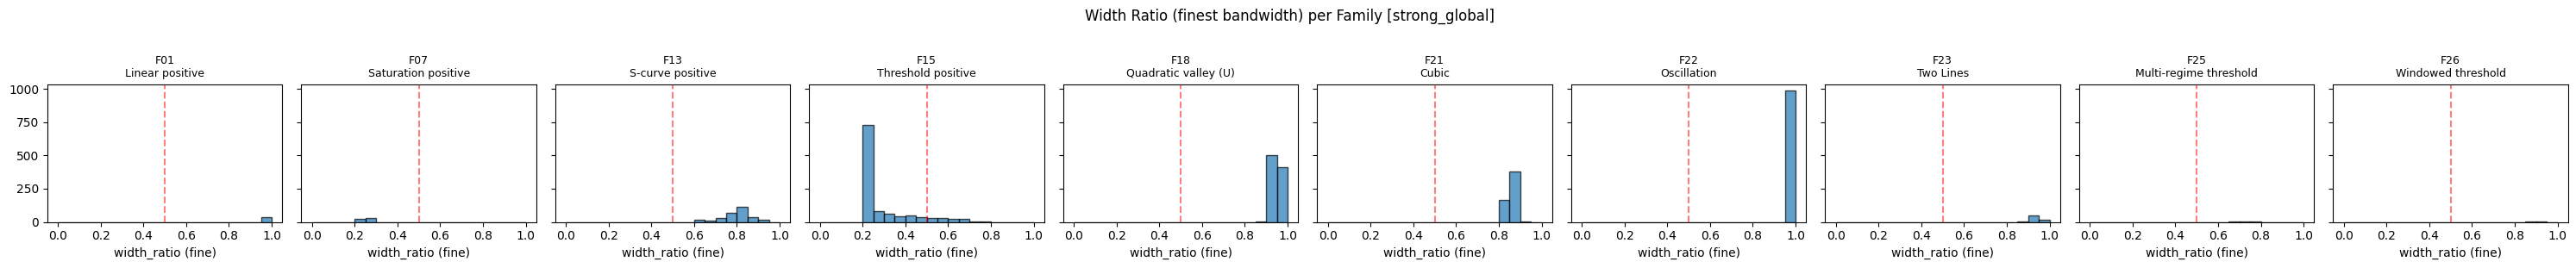


=== Width Ratio Distribution [intermediate_global] ===
width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean,wr_mean_std
family_id,family_name,,,,,,,
F01,Linear positive,155,0.991,0.012,0.956,1.000,0.998,0.003
F03,Power convex positive,78,0.812,0.059,0.694,0.911,0.807,0.052
F05,Power concave positive,77,0.911,0.046,0.828,1.000,0.975,0.018
F07,Saturation positive,582,0.247,0.012,0.217,0.272,0.360,0.006
F13,S-curve positive,114,0.871,0.045,0.778,0.961,0.894,0.032
F15,Threshold positive,99,0.679,0.086,0.444,0.817,0.795,0.058
F18,Quadratic valley (U),173,0.951,0.033,0.856,0.989,0.957,0.012
F21,Cubic,332,0.851,0.042,0.728,0.922,0.879,0.016
F22,Oscillation,153,0.968,0.004,0.961,0.978,0.884,0.020


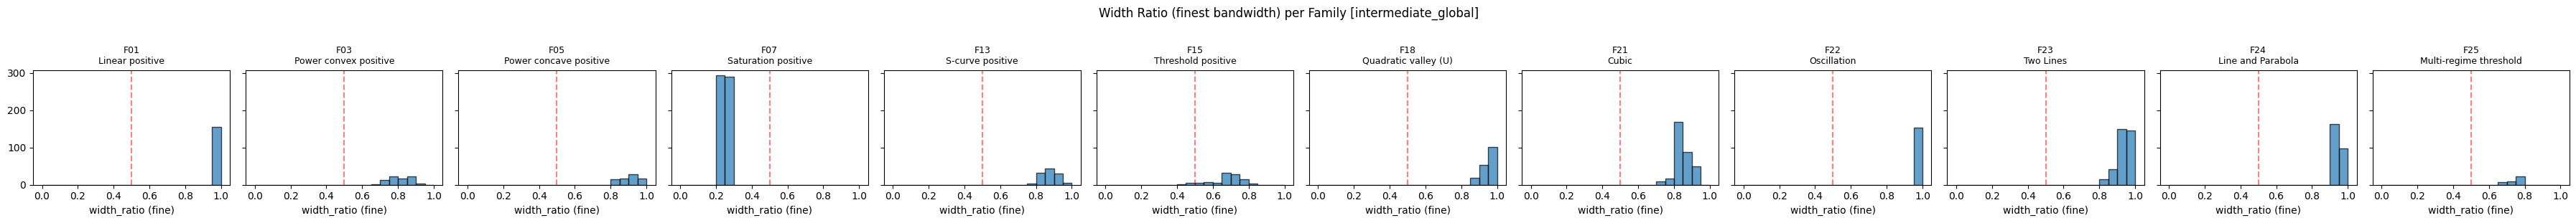

In [443]:
if RUN_METHOD_A:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== Width Ratio Distribution [{_gate}] ===')
        print(f'{"="*60}')
        print('width_ratio_fine = finest bandwidth; width_ratio_mean = mean across all bandwidths\n')

        wr_summary = sizer_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            wr_fine_mean=('width_ratio_fine', 'mean'),
            wr_fine_std=('width_ratio_fine', 'std'),
            wr_fine_min=('width_ratio_fine', 'min'),
            wr_fine_max=('width_ratio_fine', 'max'),
            wr_mean_mean=('width_ratio_mean', 'mean'),
            wr_mean_std=('width_ratio_mean', 'std'),
        ).round(3)
        display(wr_summary)

        families = sorted(sizer_df['family_id'].unique())
        n_fam = len(families)
        fig, axes = plt.subplots(1, n_fam, figsize=(3*n_fam, 3), sharey=True)
        if n_fam == 1:
            axes = [axes]
        for ax, fid in zip(axes, families):
            subset = sizer_df[sizer_df['family_id'] == fid]
            fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
            ax.hist(subset['width_ratio_fine'].dropna(), bins=20, range=(0, 1), alpha=0.7, edgecolor='black')
            ax.set_title(f'{fid}\n{fname}', fontsize=9)
            ax.set_xlabel('width_ratio (fine)')
            ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='0.5 threshold')
        fig.suptitle(f'Width Ratio (finest bandwidth) per Family [{_gate}]', y=1.02)
        plt.tight_layout()
        plt.show()

In [444]:
if RUN_METHOD_A:
    TP_SUPPORT_MIN = 3

    def tp_classify(row):
        supports = {
            0: row['n_0tp_bw'],
            1: row['n_1tp_bw'],
            2: row['n_2tp_bw'],
            'ge3': row['n_3tp_bw'] + row['n_gt3tp_bw'],
        }
        dominant = max(supports, key=supports.get)
        dominant_n = supports[dominant]
        if dominant_n < TP_SUPPORT_MIN:
            return 'Uncertain'
        if dominant == 0:
            return 'TP=0'
        elif dominant == 1:
            return 'TP=1'
        elif dominant == 2:
            return 'TP=2'
        else:
            return 'TP≥3'

    EXPECTED_TP_LABEL = {}
    for fid, props in FAMILY_CATALOGUE.items():
        tp = props.get('tp', 'N/A')
        mono = props.get('monotonicity', '')
        if tp == 0 and mono == 'monotonic':
            EXPECTED_TP_LABEL[fid] = 'TP=0'
        elif tp == 1:
            EXPECTED_TP_LABEL[fid] = 'TP=1'
        elif tp == 2:
            EXPECTED_TP_LABEL[fid] = 'TP=2'
        elif tp == 'multiple' or (isinstance(tp, int) and tp > 2):
            EXPECTED_TP_LABEL[fid] = 'TP≥3'
        else:
            EXPECTED_TP_LABEL[fid] = None

    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        sizer_df['sizer_label'] = sizer_df.apply(tp_classify, axis=1)
        sizer_dfs[_gate] = sizer_df

        print(f'\n{"="*60}')
        print(f'=== Multiscale TP classification [{_gate}] (≥{TP_SUPPORT_MIN}/5 support) ===')
        print(f'{"="*60}')
        print(f'Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <{TP_SUPPORT_MIN}/5→Uncertain\n')

        _sc = sizer_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
        _sc['total'] = _sc.sum(axis=1)
        _col_order = ['TP=0', 'TP=1', 'TP=2', 'TP≥3', 'Uncertain']
        _display_cols = [c for c in _col_order if c in _sc.columns]
        _sc_out = pd.DataFrame(index=_sc.index)
        _sc_out['family_name'] = _sc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _sc_out['Expected'] = _sc_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
        _sc_out['Total'] = [count_percent(n, n) for n in _sc['total']]
        for col in _display_cols:
            _sc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sc[col], _sc['total'])]

        accuracy = []
        for fid in _sc_out.index:
            exp = EXPECTED_TP_LABEL.get(fid)
            total = int(_sc.loc[fid, 'total'])
            if exp is None:
                accuracy.append('N/A')
            elif exp in _sc.columns:
                n_correct = int(_sc.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
            else:
                accuracy.append(f'0/{total} (0.0%)')
        _sc_out['Accuracy'] = accuracy
        display(_sc_out)

        _all = sizer_df.copy()
        _all['_expected'] = _all['family_id'].map(EXPECTED_TP_LABEL)
        _eval = _all[_all['_expected'].notna()].copy()
        if len(_eval) > 0:
            _eval['_correct'] = _eval['sizer_label'] == _eval['_expected']
            n_t = len(_eval)
            n_c = int(_eval['_correct'].sum())
            print(f'\nOverall accuracy: {n_c}/{n_t} ({n_c/n_t:.1%})')


=== Multiscale TP classification [strong_global] (≥3/5 support) ===
Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <3/5→Uncertain



,family_name,Expected,Total,TP=0,TP=1,TP=2,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,34 (100.0%),34 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),34/34 (100.0%)
F07,Saturation positive,TP=0,55 (100.0%),55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),55/55 (100.0%)
F13,S-curve positive,TP=0,282 (100.0%),278 (98.6%),0 (0.0%),0 (0.0%),0 (0.0%),4 (1.4%),278/282 (98.6%)
F15,Threshold positive,TP=0,"1,112 (100.0%)","1,012 (91.0%)",60 (5.4%),0 (0.0%),0 (0.0%),40 (3.6%),1012/1112 (91.0%)
F18,Quadratic valley (U),TP=1,916 (100.0%),0 (0.0%),916 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),916/916 (100.0%)
F21,Cubic,TP=2,549 (100.0%),0 (0.0%),0 (0.0%),549 (100.0%),0 (0.0%),0 (0.0%),549/549 (100.0%)
F22,Oscillation,TP≥3,987 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),987 (100.0%),0 (0.0%),987/987 (100.0%)
F23,Two Lines,None,71 (100.0%),71 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),N/A
F25,Multi-regime threshold,TP≥3,10 (100.0%),1 (10.0%),0 (0.0%),5 (50.0%),0 (0.0%),4 (40.0%),0/10 (0.0%)



Overall accuracy: 3841/3955 (97.1%)

=== Multiscale TP classification [intermediate_global] (≥3/5 support) ===
Rule: TP=0 | TP=1 | TP=2 | TP≥3 | <3/5→Uncertain



,family_name,Expected,Total,TP=0,TP=1,TP=2,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,155 (100.0%),155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,TP=0,78 (100.0%),58 (74.4%),16 (20.5%),0 (0.0%),0 (0.0%),4 (5.1%),58/78 (74.4%)
F05,Power concave positive,TP=0,77 (100.0%),77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,TP=0,582 (100.0%),582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),582/582 (100.0%)
F13,S-curve positive,TP=0,114 (100.0%),84 (73.7%),0 (0.0%),0 (0.0%),0 (0.0%),30 (26.3%),84/114 (73.7%)
F15,Threshold positive,TP=0,99 (100.0%),25 (25.3%),28 (28.3%),0 (0.0%),9 (9.1%),37 (37.4%),25/99 (25.3%)
F18,Quadratic valley (U),TP=1,173 (100.0%),0 (0.0%),173 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),173/173 (100.0%)
F21,Cubic,TP=2,332 (100.0%),0 (0.0%),0 (0.0%),332 (100.0%),0 (0.0%),0 (0.0%),332/332 (100.0%)
F22,Oscillation,TP≥3,153 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),153 (100.0%),0 (0.0%),153/153 (100.0%)



Overall accuracy: 1639/2059 (79.6%)



=== Width Ratio within TP=0 [strong_global] (1451 cases) ===
Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean
family_id,family_name,,,,,,
F01,Linear positive,34,0.998,0.006,0.978,1.000,1.000
F07,Saturation positive,55,0.247,0.006,0.239,0.256,0.360
F13,S-curve positive,278,0.796,0.069,0.611,0.933,0.874
F15,Threshold positive,1012,0.267,0.091,0.200,0.678,0.568
F23,Two Lines,71,0.935,0.032,0.856,0.989,0.981
F25,Multi-regime threshold,1,0.767,NaN,0.767,0.767,0.660


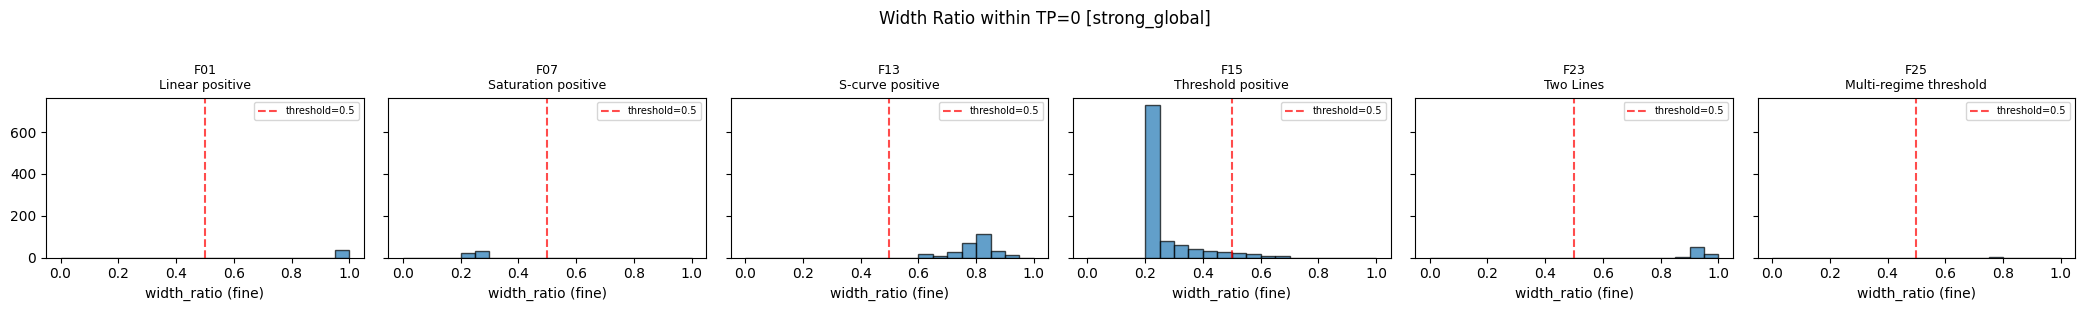


=== Width Ratio within TP=0 [intermediate_global] (1546 cases) ===
Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)



,,n,wr_fine_mean,wr_fine_std,wr_fine_min,wr_fine_max,wr_mean_mean
family_id,family_name,,,,,,
F01,Linear positive,155,0.991,0.012,0.956,1.000,0.998
F03,Power convex positive,58,0.799,0.059,0.694,0.894,0.793
F05,Power concave positive,77,0.911,0.046,0.828,1.000,0.975
F07,Saturation positive,582,0.247,0.012,0.217,0.272,0.360
F13,S-curve positive,84,0.873,0.050,0.778,0.961,0.895
F15,Threshold positive,25,0.663,0.053,0.550,0.733,0.792
F23,Two Lines,352,0.942,0.038,0.844,0.994,0.984
F24,Line and Parabola,209,0.945,0.020,0.917,0.989,0.975
F25,Multi-regime threshold,4,0.767,0.000,0.767,0.767,0.660


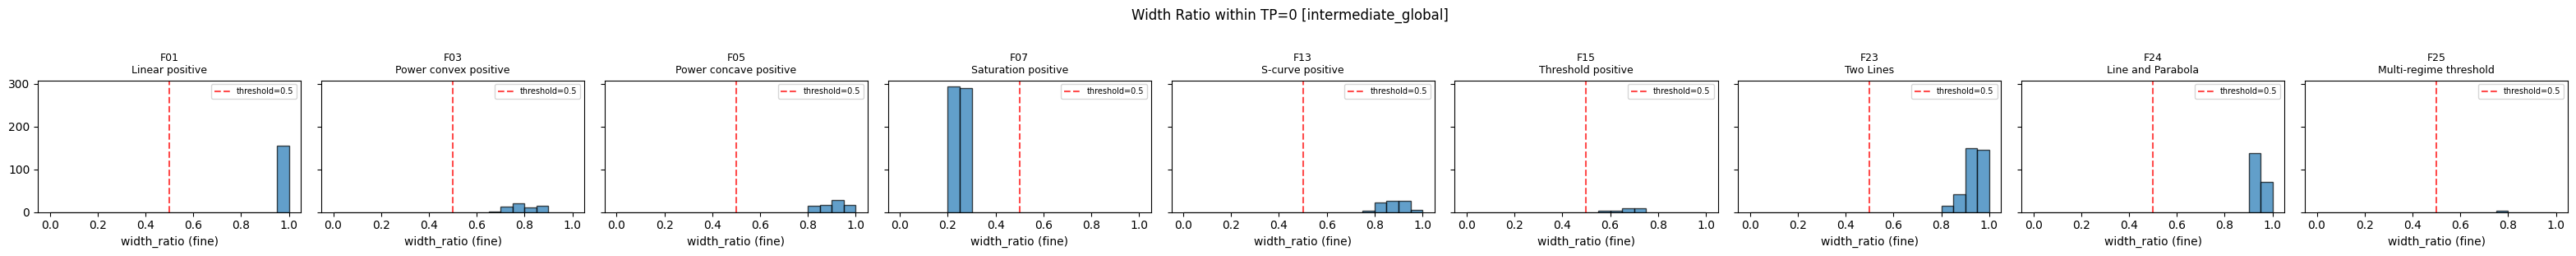

In [445]:
if RUN_METHOD_A:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        tp0_df = sizer_df[sizer_df['sizer_label'] == 'TP=0'].copy()
        n_tp0 = len(tp0_df)
        print(f'\n{"="*60}')
        print(f'=== Width Ratio within TP=0 [{_gate}] ({n_tp0} cases) ===')
        print(f'{"="*60}')
        print('Goal: separate S-curve (wide derivative) from Threshold (narrow derivative)\n')

        if n_tp0 > 0:
            tp0_wr_summary = tp0_df.groupby(['family_id', 'family_name']).agg(
                n=('case_id', 'size'),
                wr_fine_mean=('width_ratio_fine', 'mean'),
                wr_fine_std=('width_ratio_fine', 'std'),
                wr_fine_min=('width_ratio_fine', 'min'),
                wr_fine_max=('width_ratio_fine', 'max'),
                wr_mean_mean=('width_ratio_mean', 'mean'),
            ).round(3)
            display(tp0_wr_summary)

            families_tp0 = sorted(tp0_df['family_id'].unique())
            n_fam = len(families_tp0)
            if n_fam > 0:
                fig, axes = plt.subplots(1, n_fam, figsize=(3.5*n_fam, 3), sharey=True)
                if n_fam == 1:
                    axes = [axes]
                for ax, fid in zip(axes, families_tp0):
                    subset = tp0_df[tp0_df['family_id'] == fid]
                    fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
                    ax.hist(subset['width_ratio_fine'].dropna(), bins=20, range=(0, 1),
                            alpha=0.7, edgecolor='black')
                    ax.set_title(f'{fid}\n{fname}', fontsize=9)
                    ax.set_xlabel('width_ratio (fine)')
                    ax.axvline(WIDTH_RATIO_THRESHOLD, color='red', ls='--', alpha=0.7,
                               label=f'threshold={WIDTH_RATIO_THRESHOLD}')
                    ax.legend(fontsize=7)
                fig.suptitle(f'Width Ratio within TP=0 [{_gate}]', y=1.02)
                plt.tight_layout()
                plt.show()
        else:
            print('No TP=0 cases found.')

In [446]:
if RUN_METHOD_A:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        if sizer_df is None or len(sizer_df) == 0:
            continue

        tp0_mask = sizer_df['sizer_label'] == 'TP=0'
        n_tp0 = tp0_mask.sum()
        tp0_families = sizer_df.loc[tp0_mask, 'family_id'].unique()

        print(f'\n{"="*60}')
        print(f'=== Width-ratio sub-classification [{_gate}] ===')
        print(f'{"="*60}')
        print(f'TP=0 cases: {n_tp0} across {len(tp0_families)} families')

        if USE_WIDTH_RATIO_SUBCLASS and n_tp0 > 0:
            narrow_mask = tp0_mask & (sizer_df['width_ratio_fine'] < WIDTH_RATIO_THRESHOLD)
            n_narrow = narrow_mask.sum()
            n_wide = n_tp0 - n_narrow
            print(f'Width-ratio sub-classification ON (threshold = {WIDTH_RATIO_THRESHOLD})')
            print(f'  wide (wr >= {WIDTH_RATIO_THRESHOLD}): {n_wide} -> keep TP=0')
            print(f'  narrow (wr < {WIDTH_RATIO_THRESHOLD}): {n_narrow} -> relabel Threshold\n')

            sizer_df.loc[narrow_mask, 'sizer_label'] = 'Threshold'
            sizer_dfs[_gate] = sizer_df

            _tp0_df = sizer_df[sizer_df['family_id'].isin(tp0_families)].copy()
            _sub = _tp0_df.groupby(['family_id', 'sizer_label']).size().unstack(fill_value=0)
            _sub['total'] = _sub.sum(axis=1)
            _col_order = ['TP=0', 'Threshold', 'TP=1', 'TP≥3', 'Uncertain']
            _sub_display = [c for c in _col_order if c in _sub.columns]

            _sub_out = pd.DataFrame(index=_sub.index)
            _sub_out['family_name'] = _sub_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
            _sub_out['Expected'] = _sub_out.index.map(lambda f: EXPECTED_TP_LABEL.get(f, 'N/A'))
            _sub_out['Total'] = [count_percent(n, n) for n in _sub['total']]
            for col in _sub_display:
                _sub_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_sub[col], _sub['total'])]

            accuracy = []
            for fid in _sub_out.index:
                exp = EXPECTED_TP_LABEL.get(fid)
                total = int(_sub.loc[fid, 'total'])
                if exp is None:
                    accuracy.append('N/A')
                elif exp in _sub.columns:
                    n_correct = int(_sub.loc[fid, exp])
                    accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
                else:
                    accuracy.append(f'0/{total} (0.0%)')
            _sub_out['Accuracy'] = accuracy

            print(f'TP=0 sub-classification (wr_fine < {WIDTH_RATIO_THRESHOLD} -> Threshold):')
            print(f'Only showing families that had TP=0 cases\n')
            display(_sub_out)
        else:
            print('Width-ratio sub-classification OFF or no TP=0 cases')


=== Width-ratio sub-classification [strong_global] ===
TP=0 cases: 1451 across 6 families
Width-ratio sub-classification ON (threshold = 0.5)
  wide (wr >= 0.5): 431 -> keep TP=0
  narrow (wr < 0.5): 1020 -> relabel Threshold

TP=0 sub-classification (wr_fine < 0.5 -> Threshold):
Only showing families that had TP=0 cases



,family_name,Expected,Total,TP=0,Threshold,TP=1,Uncertain,Accuracy
family_id,,,,,,,,
F01,Linear positive,TP=0,34 (100.0%),34 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),34/34 (100.0%)
F07,Saturation positive,TP=0,55 (100.0%),0 (0.0%),55 (100.0%),0 (0.0%),0 (0.0%),0/55 (0.0%)
F13,S-curve positive,TP=0,282 (100.0%),278 (98.6%),0 (0.0%),0 (0.0%),4 (1.4%),278/282 (98.6%)
F15,Threshold positive,TP=0,"1,112 (100.0%)",47 (4.2%),965 (86.8%),60 (5.4%),40 (3.6%),47/1112 (4.2%)
F23,Two Lines,None,71 (100.0%),71 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),N/A
F25,Multi-regime threshold,TP≥3,10 (100.0%),1 (10.0%),0 (0.0%),0 (0.0%),4 (40.0%),0/10 (0.0%)



=== Width-ratio sub-classification [intermediate_global] ===
TP=0 cases: 1546 across 9 families
Width-ratio sub-classification ON (threshold = 0.5)
  wide (wr >= 0.5): 964 -> keep TP=0
  narrow (wr < 0.5): 582 -> relabel Threshold

TP=0 sub-classification (wr_fine < 0.5 -> Threshold):
Only showing families that had TP=0 cases



,family_name,Expected,Total,TP=0,Threshold,TP=1,TP≥3,Uncertain,Accuracy
family_id,,,,,,,,,
F01,Linear positive,TP=0,155 (100.0%),155 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,TP=0,78 (100.0%),58 (74.4%),0 (0.0%),16 (20.5%),0 (0.0%),4 (5.1%),58/78 (74.4%)
F05,Power concave positive,TP=0,77 (100.0%),77 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,TP=0,582 (100.0%),0 (0.0%),582 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0/582 (0.0%)
F13,S-curve positive,TP=0,114 (100.0%),84 (73.7%),0 (0.0%),0 (0.0%),0 (0.0%),30 (26.3%),84/114 (73.7%)
F15,Threshold positive,TP=0,99 (100.0%),25 (25.3%),0 (0.0%),28 (28.3%),9 (9.1%),37 (37.4%),25/99 (25.3%)
F23,Two Lines,None,352 (100.0%),352 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),N/A
F24,Line and Parabola,TP=1,260 (100.0%),209 (80.4%),0 (0.0%),0 (0.0%),26 (10.0%),25 (9.6%),0/260 (0.0%)
F25,Multi-regime threshold,TP≥3,36 (100.0%),4 (11.1%),0 (0.0%),0 (0.0%),0 (0.0%),12 (33.3%),0/36 (0.0%)


## Method C — Conditional Dip Test (branch / multimodality detection)

For each x-bin, test whether Y|X is multimodal using Hartigan's dip test.
Persistent bimodality across bins → branching signal (e.g. F23 Two Lines).
Also counts the number of modes per bin via KDE peak detection.

In [447]:
if RUN_METHOD_C:
    from scipy.signal import argrelextrema
    from scipy.stats import gaussian_kde
    try:
        from diptest import diptest as diptest_func
    except ImportError:
        diptest_func = None
        print('WARNING: diptest not installed')

    def conditional_dip_analysis(x, y, n_bins=8, kde_bw='silverman'):
        """Per-bin dip test + KDE mode count on Y|X."""
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 30 or diptest_func is None:
            return None

        bin_edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
        bin_edges[0] -= 1e-10
        bin_idx = np.digitize(x, bin_edges[1:-1])

        bin_results = []
        for b in range(n_bins):
            y_bin = y[bin_idx == b]
            n_bin = len(y_bin)
            if n_bin < 10:
                bin_results.append({
                    'bin': b, 'n': n_bin,
                    'dip_stat': np.nan, 'dip_p': np.nan, 'dip_sig': False,
                    'n_modes': np.nan,
                })
                continue

            dip_stat, dip_p = diptest_func(y_bin)
            dip_sig = dip_p < 0.05

            # KDE mode count
            try:
                kde = gaussian_kde(y_bin, bw_method=kde_bw)
                y_grid = np.linspace(y_bin.min(), y_bin.max(), 200)
                density = kde(y_grid)
                peaks = argrelextrema(density, np.greater, order=5)[0]
                n_modes = max(len(peaks), 1)
            except Exception:
                n_modes = np.nan

            bin_results.append({
                'bin': b, 'n': n_bin,
                'dip_stat': float(dip_stat), 'dip_p': float(dip_p),
                'dip_sig': bool(dip_sig), 'n_modes': int(n_modes) if not np.isnan(n_modes) else np.nan,
            })

        n_sig = sum(1 for r in bin_results if r['dip_sig'])
        frac_sig = n_sig / n_bins
        mode_counts = [r['n_modes'] for r in bin_results if not np.isnan(r['n_modes'])]
        median_modes = float(np.median(mode_counts)) if mode_counts else np.nan

        return {
            'bin_results': bin_results,
            'n_bins': n_bins,
            'n_sig_bins': n_sig,
            'frac_sig': frac_sig,
            'median_modes': median_modes,
        }

    print('Conditional dip test helpers defined.')

Conditional dip test helpers defined.


In [448]:
if RUN_METHOD_C:
    import time as _time
    cond_dip_dfs = {}

    for _gate in MIC_ANALYSIS_GATES:
        complex_data = complex_datas.get(_gate)
        if complex_data is None or len(complex_data) == 0:
            print(f'[{_gate}] No complex cases, skipping Method C.')
            continue

        print(f'\n{"="*60}')
        print(f'=== Conditional Dip Test [{_gate}] — {len(complex_data):,} cases ===')
        print(f'{"="*60}')

        cond_dip_results = []
        t0 = _time.time()

        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'Cond. dip [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)
            result = conditional_dip_analysis(x, y)

            cid = row['case_id']
            fid = row['family_id']

            if result is not None:
                cond_dip_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_sig_bins': result['n_sig_bins'],
                    'frac_sig': result['frac_sig'],
                    'median_modes': result['median_modes'],
                    'is_branch': result['frac_sig'] >= 0.5,
                })
            else:
                cond_dip_results.append({
                    'case_id': cid, 'family_id': fid,
                    'n_sig_bins': 0, 'frac_sig': 0.0,
                    'median_modes': np.nan, 'is_branch': False,
                })

        print(f'Conditional dip test: {len(cond_dip_results):,} cases in {_time.time()-t0:.1f}s')

        cond_dip_df = pd.DataFrame(cond_dip_results)
        cond_dip_df['family_name'] = cond_dip_df['family_id'].map(
            lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')
        )
        cond_dip_dfs[_gate] = cond_dip_df


=== Conditional Dip Test [strong_global] — 4,026 cases ===


Cond. dip [strong_global]: 100%|██████████| 4026/4026 [02:40<00:00, 25.11it/s]


Conditional dip test: 4,026 cases in 160.3s

=== Conditional Dip Test [intermediate_global] — 2,411 cases ===


Cond. dip [intermediate_global]: 100%|██████████| 2411/2411 [01:44<00:00, 23.02it/s]

Conditional dip test: 2,411 cases in 104.8s



=== Method C: Branch Detection [strong_global] ===
Rule: >= 50% of x-bins with dip p<0.05 -> Branch
Also reports median KDE mode count per case



,,n,frac_sig_mean,frac_sig_std,median_modes_mean,n_branch,branch_rate
family_id,family_name,,,,,,
F01,Linear positive,34,0.000,0.000,1.000,0,0 (0.0%)
F07,Saturation positive,55,0.030,0.072,1.036,0,0 (0.0%)
F13,S-curve positive,282,0.000,0.000,1.000,0,0 (0.0%)
F15,Threshold positive,1112,0.018,0.044,1.076,0,0 (0.0%)
F18,Quadratic valley (U),916,0.011,0.035,1.100,0,0 (0.0%)
F21,Cubic,549,0.014,0.040,1.093,0,0 (0.0%)
F22,Oscillation,987,0.005,0.025,1.363,0,0 (0.0%)
F23,Two Lines,71,0.871,0.021,2.000,71,71 (100.0%)
F25,Multi-regime threshold,10,0.012,0.040,2.050,0,0 (0.0%)


,family_name,Expected,Total,Non-branch,Branch,Accuracy
family_id,,,,,,
F01,Linear positive,Non-branch,34 (100.0%),34 (100.0%),0 (0.0%),34/34 (100.0%)
F07,Saturation positive,Non-branch,55 (100.0%),55 (100.0%),0 (0.0%),55/55 (100.0%)
F13,S-curve positive,Non-branch,282 (100.0%),282 (100.0%),0 (0.0%),282/282 (100.0%)
F15,Threshold positive,Non-branch,"1,112 (100.0%)","1,112 (100.0%)",0 (0.0%),1112/1112 (100.0%)
F18,Quadratic valley (U),Non-branch,916 (100.0%),916 (100.0%),0 (0.0%),916/916 (100.0%)
F21,Cubic,Non-branch,549 (100.0%),549 (100.0%),0 (0.0%),549/549 (100.0%)
F22,Oscillation,Non-branch,987 (100.0%),987 (100.0%),0 (0.0%),987/987 (100.0%)
F23,Two Lines,Non-branch,71 (100.0%),0 (0.0%),71 (100.0%),0/71 (0.0%)
F25,Multi-regime threshold,Non-branch,10 (100.0%),10 (100.0%),0 (0.0%),10/10 (100.0%)



Overall accuracy: 3955/4026 (98.2%)


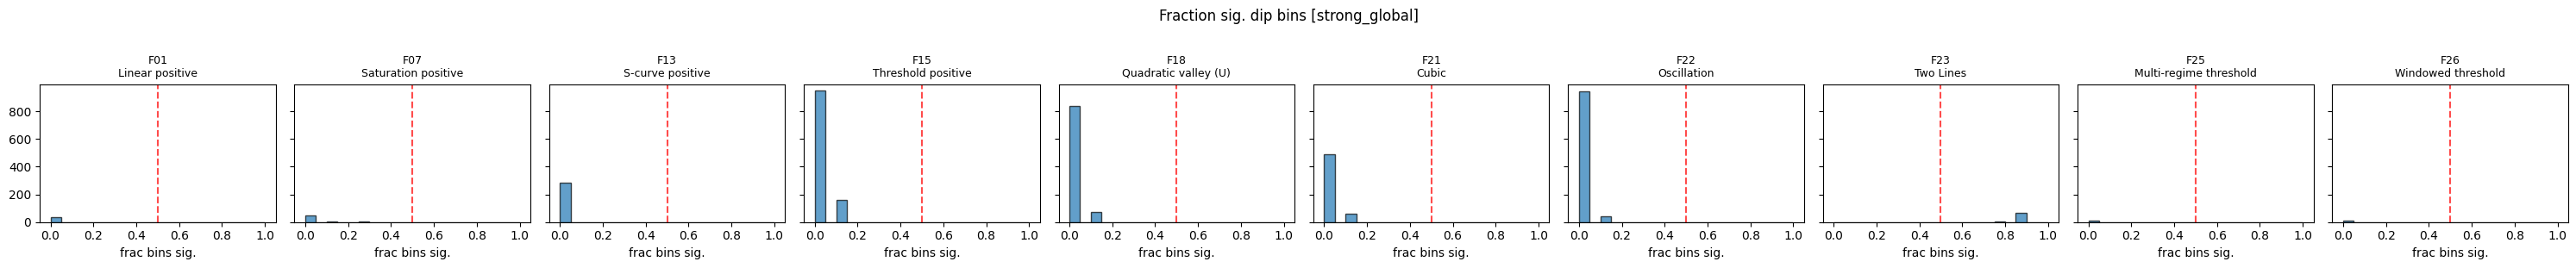


=== Method C: Branch Detection [intermediate_global] ===
Rule: >= 50% of x-bins with dip p<0.05 -> Branch
Also reports median KDE mode count per case



,,n,frac_sig_mean,frac_sig_std,median_modes_mean,n_branch,branch_rate
family_id,family_name,,,,,,
F01,Linear positive,155,0.000,0.000,1.000,0,0 (0.0%)
F03,Power convex positive,78,0.000,0.000,1.000,0,0 (0.0%)
F05,Power concave positive,77,0.006,0.028,1.000,0,0 (0.0%)
F07,Saturation positive,582,0.012,0.038,1.000,0,0 (0.0%)
F13,S-curve positive,114,0.000,0.000,1.000,0,0 (0.0%)
F15,Threshold positive,99,0.014,0.039,1.000,0,0 (0.0%)
F18,Quadratic valley (U),173,0.000,0.000,1.009,0,0 (0.0%)
F21,Cubic,332,0.008,0.031,1.002,0,0 (0.0%)
F22,Oscillation,153,0.000,0.000,1.000,0,0 (0.0%)


,family_name,Expected,Total,Non-branch,Branch,Accuracy
family_id,,,,,,
F01,Linear positive,Non-branch,155 (100.0%),155 (100.0%),0 (0.0%),155/155 (100.0%)
F03,Power convex positive,Non-branch,78 (100.0%),78 (100.0%),0 (0.0%),78/78 (100.0%)
F05,Power concave positive,Non-branch,77 (100.0%),77 (100.0%),0 (0.0%),77/77 (100.0%)
F07,Saturation positive,Non-branch,582 (100.0%),582 (100.0%),0 (0.0%),582/582 (100.0%)
F13,S-curve positive,Non-branch,114 (100.0%),114 (100.0%),0 (0.0%),114/114 (100.0%)
F15,Threshold positive,Non-branch,99 (100.0%),99 (100.0%),0 (0.0%),99/99 (100.0%)
F18,Quadratic valley (U),Non-branch,173 (100.0%),173 (100.0%),0 (0.0%),173/173 (100.0%)
F21,Cubic,Non-branch,332 (100.0%),332 (100.0%),0 (0.0%),332/332 (100.0%)
F22,Oscillation,Non-branch,153 (100.0%),153 (100.0%),0 (0.0%),153/153 (100.0%)



Overall accuracy: 1799/2411 (74.6%)


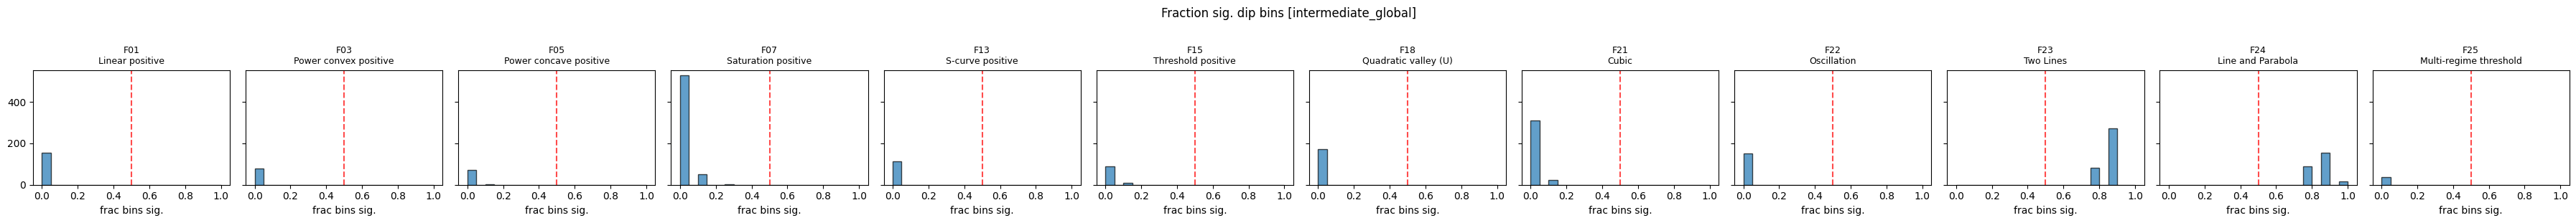

In [449]:
if RUN_METHOD_C:
    import matplotlib.pyplot as plt
    BRANCH_FRAC_THRESHOLD = 0.5

    EXPECTED_BRANCH = {}
    for fid, props in FAMILY_CATALOGUE.items():
        if props.get('special_shape', '') in ('two_lines', 'multi_branch'):
            EXPECTED_BRANCH[fid] = 'Branch'
        else:
            EXPECTED_BRANCH[fid] = 'Non-branch'

    for _gate in MIC_ANALYSIS_GATES:
        cond_dip_df = cond_dip_dfs.get(_gate)
        if cond_dip_df is None or len(cond_dip_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== Method C: Branch Detection [{_gate}] ===')
        print(f'{"="*60}')
        print(f'Rule: >= {BRANCH_FRAC_THRESHOLD:.0%} of x-bins with dip p<0.05 -> Branch')
        print(f'Also reports median KDE mode count per case\n')

        _cd_summary = cond_dip_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            frac_sig_mean=('frac_sig', 'mean'),
            frac_sig_std=('frac_sig', 'std'),
            median_modes_mean=('median_modes', 'mean'),
            n_branch=('is_branch', 'sum'),
        )
        _cd_summary['branch_rate'] = _cd_summary.apply(
            lambda r: count_percent(int(r['n_branch']), int(r['n'])), axis=1
        )
        _cd_summary = _cd_summary.round(3)
        display(_cd_summary)

        cond_dip_df['cond_dip_label'] = np.where(cond_dip_df['is_branch'], 'Branch', 'Non-branch')
        cond_dip_dfs[_gate] = cond_dip_df

        _cd_ct = cond_dip_df.groupby(['family_id', 'cond_dip_label']).size().unstack(fill_value=0)
        _cd_ct['total'] = _cd_ct.sum(axis=1)
        _cd_col_order = ['Non-branch', 'Branch']
        _cd_display = [c for c in _cd_col_order if c in _cd_ct.columns]

        _cd_out = pd.DataFrame(index=_cd_ct.index)
        _cd_out['family_name'] = _cd_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _cd_out['Expected'] = _cd_out.index.map(lambda f: EXPECTED_BRANCH.get(f, 'N/A'))
        _cd_out['Total'] = [count_percent(n, n) for n in _cd_ct['total']]
        for col in _cd_display:
            _cd_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_cd_ct[col], _cd_ct['total'])]

        accuracy = []
        for fid in _cd_out.index:
            exp = EXPECTED_BRANCH.get(fid)
            total = int(_cd_ct.loc[fid, 'total'])
            if exp is None or exp not in _cd_ct.columns:
                accuracy.append('N/A')
            else:
                n_correct = int(_cd_ct.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
        _cd_out['Accuracy'] = accuracy
        display(_cd_out)

        cond_dip_df['_expected'] = cond_dip_df['family_id'].map(EXPECTED_BRANCH)
        _eval_c = cond_dip_df[cond_dip_df['_expected'].notna()].copy()
        if len(_eval_c) > 0:
            _eval_c['_correct'] = _eval_c['cond_dip_label'] == _eval_c['_expected']
            n_tc = len(_eval_c)
            n_cc = int(_eval_c['_correct'].sum())
            print(f'\nOverall accuracy: {n_cc}/{n_tc} ({n_cc/n_tc:.1%})')

        families_c = sorted(cond_dip_df['family_id'].unique())
        n_fam = len(families_c)
        if n_fam > 0:
            fig, axes = plt.subplots(1, n_fam, figsize=(3*n_fam, 3), sharey=True)
            if n_fam == 1:
                axes = [axes]
            for ax, fid in zip(axes, families_c):
                subset = cond_dip_df[cond_dip_df['family_id'] == fid]
                fname = subset['family_name'].iloc[0] if len(subset) > 0 else fid
                ax.hist(subset['frac_sig'].dropna(), bins=20, range=(0, 1),
                        alpha=0.7, edgecolor='black')
                ax.set_title(f'{fid}\n{fname}', fontsize=9)
                ax.set_xlabel('frac bins sig.')
                ax.axvline(BRANCH_FRAC_THRESHOLD, color='red', ls='--', alpha=0.7)
            fig.suptitle(f'Fraction sig. dip bins [{_gate}]', y=1.02)
            plt.tight_layout()
            plt.show()

## Method B — KL / QR / HD (distributional tests)

From: *"Thresholds for ecological responses to global change do not emerge from empirical data"*

- **KL**: Does the overall distribution of Y change with X? (permutation test on Y)
- **QR**: Does the spread of the Y distribution change substantially with X? (permutation test on X)
- **HD**: Does Y have multiple modes / two distinct states? (Hartigan's dip test)

Decision rule:
- KL+, QR+, HD+ → Threshold
- KL+, QR+, HD− → Cubic
- otherwise → S-shaped

In [450]:
if RUN_METHOD_B:
    from scipy.stats import gaussian_kde
    from diptest import diptest as diptest_func

    def _conditional_density_kde(x, y, n_grid_x=30, n_grid_y=50):
        gx = np.linspace(x.min(), x.max(), n_grid_x)
        gy = np.linspace(y.min(), y.max(), n_grid_y)
        GX, GY = np.meshgrid(gx, gy, indexing='ij')
        grid_pts = np.vstack([GX.ravel(), GY.ravel()])
        try:
            kde2d = gaussian_kde(np.vstack([x, y]), bw_method='silverman')
            density_2d = kde2d(grid_pts).reshape(n_grid_x, n_grid_y)
        except np.linalg.LinAlgError:
            return None
        kde_x = gaussian_kde(x, bw_method='silverman')
        p_x = kde_x(gx)
        p_x = p_x / p_x.sum()
        p_cond = np.zeros_like(density_2d)
        for ix in range(n_grid_x):
            col_sum = density_2d[ix].sum()
            if col_sum > 1e-20:
                p_cond[ix] = density_2d[ix] / col_sum
            else:
                p_cond[ix] = 1.0 / n_grid_y
        kde_y = gaussian_kde(y, bw_method='silverman')
        p_marginal_y = kde_y(gy)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()
        return gx, gy, p_cond, p_marginal_y, p_x

    def _conditional_density_hist(x, y, n_grid_x=30, n_grid_y=50):
        hist2d, xedges, yedges = np.histogram2d(x, y, bins=[n_grid_x, n_grid_y])
        gx = 0.5 * (xedges[:-1] + xedges[1:])
        gy = 0.5 * (yedges[:-1] + yedges[1:])
        hist2d = hist2d + 1e-10
        p_x = hist2d.sum(axis=1)
        p_x = p_x / p_x.sum()
        p_cond = hist2d / hist2d.sum(axis=1, keepdims=True)
        p_marginal_y = hist2d.sum(axis=0)
        p_marginal_y = p_marginal_y / p_marginal_y.sum()
        return gx, gy, p_cond, p_marginal_y, p_x

    def _conditional_density(x, y, n_grid_x=30, n_grid_y=50):
        if KL_METHOD == 'kde':
            return _conditional_density_kde(x, y, n_grid_x, n_grid_y)
        else:
            return _conditional_density_hist(x, y, n_grid_x, n_grid_y)

    def _kl_from_cond(p_cond, p_marginal_y, p_x):
        kl = 0.0
        for ix in range(p_cond.shape[0]):
            pc = np.maximum(p_cond[ix], 1e-20)
            pm = np.maximum(p_marginal_y, 1e-20)
            kl += p_x[ix] * np.sum(pc * np.log(pc / pm))
        return float(kl)

    def _qr_from_cond(p_cond, gy):
        iqrs = []
        for ix in range(p_cond.shape[0]):
            cdf = np.cumsum(p_cond[ix])
            cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
            q05 = gy[np.searchsorted(cdf, 0.05)]
            q95 = gy[np.searchsorted(cdf, 0.95, side='right').clip(max=len(gy)-1)]
            iqrs.append(q95 - q05)
        iqrs = np.array(iqrs)
        q01_iqr = np.percentile(iqrs, 1)
        q99_iqr = np.percentile(iqrs, 99)
        if q01_iqr < 1e-10:
            return np.nan
        return float(q99_iqr / q01_iqr)

    def klqr_test(x, y, n_perm=99):
        valid = np.isfinite(x) & np.isfinite(y)
        x, y = x[valid], y[valid]
        if len(x) < 20:
            return np.nan, np.nan, np.nan, np.nan
        result = _conditional_density(x, y)
        if result is None:
            return np.nan, np.nan, np.nan, np.nan
        gx, gy, p_cond, p_marginal_y, p_x = result
        kl_obs = _kl_from_cond(p_cond, p_marginal_y, p_x)
        qr_obs = _qr_from_cond(p_cond, gy)
        kl_count = 0
        qr_count = 0
        rng = np.random.RandomState(42)
        for _ in range(n_perm):
            y_perm = rng.permutation(y)
            res_perm = _conditional_density(x, y_perm)
            if res_perm is None:
                continue
            _, gy_p, pc_p, pm_p, px_p = res_perm
            kl_perm = _kl_from_cond(pc_p, pm_p, px_p)
            if kl_perm >= kl_obs:
                kl_count += 1
            qr_perm = _qr_from_cond(pc_p, gy_p)
            if not np.isnan(qr_perm) and not np.isnan(qr_obs) and qr_perm >= qr_obs:
                qr_count += 1
        kl_p = float((kl_count + 1) / (n_perm + 1))
        qr_p = float((qr_count + 1) / (n_perm + 1)) if not np.isnan(qr_obs) else np.nan
        return kl_obs, kl_p, qr_obs, qr_p

    def hd_test(y):
        valid = np.isfinite(y)
        y = y[valid]
        if len(y) < 20:
            return np.nan, np.nan
        dip, pval = diptest_func(y)
        return float(dip), float(pval)

    print(f'KL/QR/HD helpers defined.  KL_METHOD={KL_METHOD!r}, n_perm=99 (KL+QR shared)')

KL/QR/HD helpers defined.  KL_METHOD='histogram', n_perm=99 (KL+QR shared)


In [451]:
if RUN_METHOD_B:
    klqrhd_dfs = {}
    np.random.seed(42)

    for _gate in MIC_ANALYSIS_GATES:
        complex_data = complex_datas.get(_gate)
        if complex_data is None or len(complex_data) == 0:
            print(f'[{_gate}] No complex cases, skipping Method B.')
            continue

        print(f'\n{"="*60}')
        print(f'=== KL/QR/HD [{_gate}] — {len(complex_data):,} cases (KL_METHOD={KL_METHOD!r}) ===')
        print(f'{"="*60}')

        klqrhd_results = []
        t0 = time.time()

        for idx, row in tqdm(complex_data.iterrows(), total=len(complex_data), desc=f'KL/QR/HD [{_gate}]'):
            pi = int(row['_pt_idx'])
            x = x_all[pi].astype(np.float64)
            y = y_all[pi].astype(np.float64)

            kl_stat, kl_p, qr_stat, qr_p = klqr_test(x, y)
            hd_stat, hd_p = hd_test(y)

            klqrhd_results.append({
                'case_id': row['case_id'],
                'family_id': row['family_id'],
                'kl_stat': kl_stat, 'kl_p': kl_p, 'kl_sig': kl_p < 0.05 if not np.isnan(kl_p) else np.nan,
                'qr_stat': qr_stat, 'qr_p': qr_p, 'qr_sig': qr_p < 0.05 if not np.isnan(qr_p) else np.nan,
                'hd_stat': hd_stat, 'hd_p': hd_p, 'hd_sig': hd_p < 0.05 if not np.isnan(hd_p) else np.nan,
            })

        print(f'KL/QR/HD: {len(klqrhd_results):,} cases in {time.time()-t0:.1f}s')

        klqrhd_df = pd.DataFrame(klqrhd_results)
        klqrhd_df['family_name'] = klqrhd_df['family_id'].map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        klqrhd_dfs[_gate] = klqrhd_df

        print(f'\n=== Significance rates per family [{_gate}] ===')
        _sig = klqrhd_df.groupby(['family_id', 'family_name']).agg(
            n=('case_id', 'size'),
            KL_sig=('kl_sig', lambda s: count_percent(int(s.sum()), len(s))),
            QR_sig=('qr_sig', lambda s: count_percent(int(s.sum()), len(s))),
            HD_sig=('hd_sig', lambda s: count_percent(int(s.sum()), len(s))),
        )
        display(_sig)


=== KL/QR/HD [strong_global] — 4,026 cases (KL_METHOD='histogram') ===


KL/QR/HD [strong_global]: 100%|██████████| 4026/4026 [02:56<00:00, 22.87it/s]

KL/QR/HD: 4,026 cases in 176.1s

=== Significance rates per family [strong_global] ===


,,n,KL_sig,QR_sig,HD_sig
family_id,family_name,,,,
F01,Linear positive,34,34 (100.0%),26 (76.5%),0 (0.0%)
F07,Saturation positive,55,55 (100.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,282,282 (100.0%),238 (84.4%),252 (89.4%)
F15,Threshold positive,1112,"1,112 (100.0%)","1,036 (93.2%)","1,078 (96.9%)"
F18,Quadratic valley (U),916,916 (100.0%),680 (74.2%),0 (0.0%)
F21,Cubic,549,549 (100.0%),85 (15.5%),65 (11.8%)
F22,Oscillation,987,987 (100.0%),979 (99.2%),909 (92.1%)
F23,Two Lines,71,71 (100.0%),71 (100.0%),0 (0.0%)
F25,Multi-regime threshold,10,10 (100.0%),0 (0.0%),0 (0.0%)



=== KL/QR/HD [intermediate_global] — 2,411 cases (KL_METHOD='histogram') ===


KL/QR/HD [intermediate_global]: 100%|██████████| 2411/2411 [01:44<00:00, 23.14it/s]

KL/QR/HD: 2,411 cases in 104.2s

=== Significance rates per family [intermediate_global] ===


,,n,KL_sig,QR_sig,HD_sig
family_id,family_name,,,,
F01,Linear positive,155,155 (100.0%),75 (48.4%),0 (0.0%)
F03,Power convex positive,78,78 (100.0%),0 (0.0%),0 (0.0%)
F05,Power concave positive,77,77 (100.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,582,582 (100.0%),11 (1.9%),0 (0.0%)
F13,S-curve positive,114,114 (100.0%),52 (45.6%),1 (0.9%)
F15,Threshold positive,99,99 (100.0%),15 (15.2%),0 (0.0%)
F18,Quadratic valley (U),173,173 (100.0%),53 (30.6%),0 (0.0%)
F21,Cubic,332,332 (100.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,153,153 (100.0%),98 (64.1%),10 (6.5%)



=== KL/QR/HD stat distributions [strong_global] ===


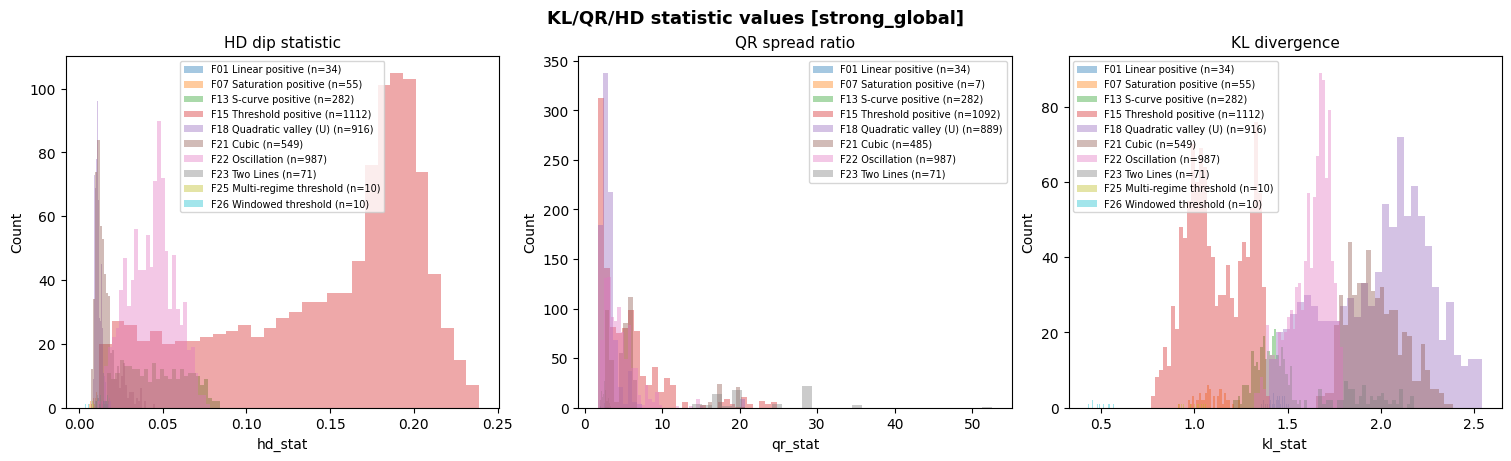


=== HD dip statistic per family [strong_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,34.0,0.0142,0.0022,0.0104,0.0118,0.0123,0.0138,0.0160,0.0173,0.0179
F07,Saturation positive,55.0,0.0102,0.0019,0.0062,0.0076,0.0091,0.0103,0.0115,0.0126,0.0143
F13,S-curve positive,282.0,0.0462,0.0181,0.0121,0.0232,0.0304,0.0451,0.0618,0.0709,0.0844
F15,Threshold positive,1112.0,0.1467,0.0590,0.0120,0.0479,0.1048,0.1696,0.1927,0.2063,0.2390
F18,Quadratic valley (U),916.0,0.0115,0.0019,0.0081,0.0095,0.0101,0.0111,0.0126,0.0140,0.0192
F21,Cubic,549.0,0.0157,0.0064,0.0071,0.0101,0.0113,0.0138,0.0180,0.0256,0.0454
F22,Oscillation,987.0,0.0435,0.0134,0.0107,0.0256,0.0334,0.0448,0.0524,0.0614,0.0780
F23,Two Lines,71.0,0.0138,0.0022,0.0096,0.0108,0.0121,0.0138,0.0156,0.0167,0.0173
F25,Multi-regime threshold,10.0,0.0086,0.0012,0.0072,0.0076,0.0079,0.0080,0.0094,0.0101,0.0109



=== QR spread ratio per family [strong_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,34.0,2.6787,0.4211,2.0487,2.2507,2.4569,2.6003,2.8051,3.4874,3.5714
F07,Saturation positive,7.0,16.1914,0.4721,15.6800,15.6800,15.8250,15.9700,16.6800,16.6800,16.6800
F13,S-curve positive,282.0,2.5756,0.3407,1.9638,2.1555,2.2920,2.5522,2.7217,3.1240,3.5369
F15,Threshold positive,1092.0,5.5057,4.3435,1.7850,2.1322,2.4733,4.1375,6.7967,10.4050,24.8400
F18,Quadratic valley (U),889.0,3.2544,2.0033,1.7500,2.2428,2.4294,2.9033,3.4275,4.0000,20.6897
F21,Cubic,485.0,6.0574,4.3830,2.5700,3.0000,3.3550,5.0000,5.7519,16.2414,20.6897
F22,Oscillation,987.0,4.5872,2.0586,2.0350,2.5868,3.1029,4.1420,5.6667,6.6260,15.2791
F23,Two Lines,71.0,23.0491,6.7712,13.8936,17.4419,17.7171,19.9607,28.9304,28.9304,52.5402
F25,Multi-regime threshold,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== KL/QR/HD stat distributions [intermediate_global] ===


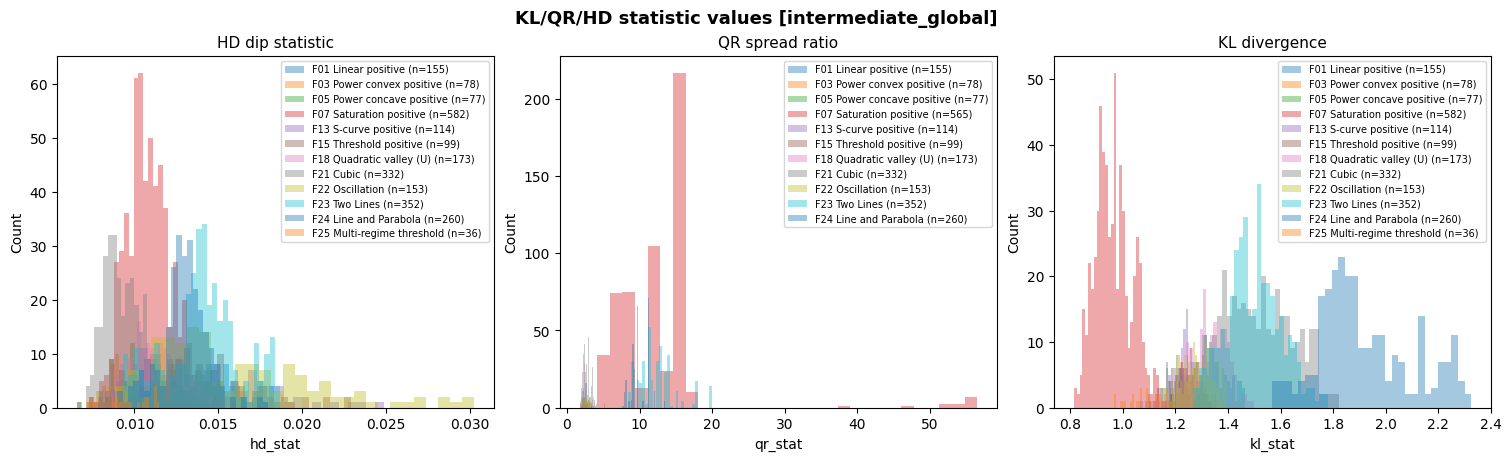


=== HD dip statistic per family [intermediate_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,155.0,0.0129,0.0025,0.0082,0.0098,0.0110,0.0128,0.0147,0.0163,0.0183
F03,Power convex positive,78.0,0.0099,0.0016,0.0073,0.0082,0.0088,0.0097,0.0105,0.0120,0.0150
F05,Power concave positive,77.0,0.0104,0.0018,0.0066,0.0085,0.0092,0.0100,0.0115,0.0131,0.0160
F07,Saturation positive,582.0,0.0108,0.0013,0.0073,0.0092,0.0100,0.0107,0.0116,0.0126,0.0161
F13,S-curve positive,114.0,0.0142,0.0033,0.0087,0.0105,0.0114,0.0138,0.0163,0.0184,0.0249
F15,Threshold positive,99.0,0.0147,0.0027,0.0103,0.0118,0.0125,0.0142,0.0161,0.0182,0.0229
F18,Quadratic valley (U),173.0,0.0114,0.0016,0.0084,0.0094,0.0102,0.0113,0.0123,0.0136,0.0160
F21,Cubic,332.0,0.0096,0.0014,0.0066,0.0081,0.0085,0.0093,0.0105,0.0114,0.0145
F22,Oscillation,153.0,0.0159,0.0047,0.0088,0.0112,0.0123,0.0144,0.0189,0.0222,0.0303



=== QR spread ratio per family [intermediate_global] ===


,family_name,count,mean,std,min,10%,25%,50%,75%,90%,max
family_id,,,,,,,,,,,
F01,Linear positive,155.0,2.6296,0.4253,2.0182,2.1756,2.3277,2.5603,2.7356,3.2710,3.8926
F03,Power convex positive,78.0,2.5321,0.3874,2.0789,2.1435,2.1925,2.3936,2.8465,3.1190,3.4054
F05,Power concave positive,77.0,2.5900,0.4037,2.1363,2.2569,2.3536,2.4855,2.6729,3.0083,4.1229
F07,Saturation positive,565.0,12.7709,7.2212,4.1300,6.9039,7.8400,12.1550,15.5500,15.6800,56.5172
F13,S-curve positive,114.0,2.5772,0.3817,1.9594,2.0994,2.2214,2.5693,2.8613,3.1123,3.3776
F15,Threshold positive,99.0,2.2476,0.2663,1.7617,1.9239,2.0714,2.2143,2.3969,2.5969,2.9393
F18,Quadratic valley (U),173.0,2.6028,0.4657,1.8710,2.1638,2.3057,2.4830,2.8185,3.4082,3.9659
F21,Cubic,332.0,2.7342,0.5102,1.8571,2.1775,2.3412,2.6620,3.0000,3.4693,5.2016
F22,Oscillation,153.0,2.5815,0.2958,2.0316,2.2040,2.3683,2.5380,2.7591,2.9668,3.3495


In [452]:
if RUN_METHOD_B:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        klqrhd_df = klqrhd_dfs.get(_gate)
        if klqrhd_df is None or len(klqrhd_df) == 0:
            continue

        print(f'\n{"="*60}')
        print(f'=== KL/QR/HD stat distributions [{_gate}] ===')
        print(f'{"="*60}')

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
        stat_cols = [
            ('hd_stat', 'HD dip statistic'),
            ('qr_stat', 'QR spread ratio'),
            ('kl_stat', 'KL divergence'),
        ]
        for ax, (col, title) in zip(axes, stat_cols):
            for fid in sorted(klqrhd_df['family_id'].unique()):
                vals = klqrhd_df.loc[klqrhd_df['family_id'] == fid, col].dropna()
                if len(vals) == 0:
                    continue
                fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
                ax.hist(vals, bins=30, alpha=0.4, label=f'{fid} {fname} (n={len(vals)})')
            ax.set_title(title, fontsize=11)
            ax.set_xlabel(col)
            ax.set_ylabel('Count')
            ax.legend(fontsize=7)
        fig.suptitle(f'KL/QR/HD statistic values [{_gate}]', fontsize=13, fontweight='bold')
        plt.show()

        print(f'\n=== HD dip statistic per family [{_gate}] ===')
        _hd_summary = klqrhd_df.groupby('family_id')['hd_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
        _hd_summary.insert(0, 'family_name', _hd_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
        display(_hd_summary)

        print(f'\n=== QR spread ratio per family [{_gate}] ===')
        _qr_summary = klqrhd_df.groupby('family_id')['qr_stat'].describe(percentiles=[.1,.25,.5,.75,.9]).round(4)
        _qr_summary.insert(0, 'family_name', _qr_summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
        display(_qr_summary)

In [453]:
if RUN_METHOD_B:
    HD_DIP_THRESHOLD = 0.02

    def klqrhd_classify(row):
        if any(np.isnan([row.get('kl_sig', np.nan), row.get('qr_sig', np.nan), row.get('hd_sig', np.nan)])):
            return 'failed'
        if row['kl_sig'] and row['qr_sig'] and not row['hd_sig']:
            return 'Cubic'
        hd_val = row.get('hd_stat', np.nan)
        if np.isnan(hd_val):
            return 'S/Threshold'
        if hd_val >= HD_DIP_THRESHOLD:
            return 'Threshold'
        else:
            return 'S-curve'

    EXPECTED_KLQRHD = {}
    for fid, props in FAMILY_CATALOGUE.items():
        shape = props.get('special_shape', '')
        if 'S-curve' in shape:
            EXPECTED_KLQRHD[fid] = 'S-curve'
        elif 'threshold' in shape.lower() and 'windowed' not in shape.lower():
            EXPECTED_KLQRHD[fid] = 'Threshold'
        elif 'cubic' in shape:
            EXPECTED_KLQRHD[fid] = 'Cubic'
        else:
            EXPECTED_KLQRHD[fid] = None

    for _gate in MIC_ANALYSIS_GATES:
        klqrhd_df = klqrhd_dfs.get(_gate)
        if klqrhd_df is None or len(klqrhd_df) == 0:
            continue

        klqrhd_df['klqrhd_label'] = klqrhd_df.apply(klqrhd_classify, axis=1)
        klqrhd_dfs[_gate] = klqrhd_df

        print(f'\n{"="*60}')
        print(f'=== KL/QR/HD classification [{_gate}] (HD_DIP_THRESHOLD={HD_DIP_THRESHOLD}) ===')
        print(f'{"="*60}')
        print(f'Rule: HD- → Cubic | HD+ & dip≥{HD_DIP_THRESHOLD} → Threshold | HD+ & dip<{HD_DIP_THRESHOLD} → S-curve\n')

        _kc = klqrhd_df.groupby(['family_id', 'klqrhd_label']).size().unstack(fill_value=0)
        _kc['total'] = _kc.sum(axis=1)
        _kc_out = pd.DataFrame(index=_kc.index)
        _kc_out['family_name'] = _kc_out.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
        _kc_out['Total'] = [count_percent(n, n) for n in _kc['total']]
        for col in sorted(_kc.columns.drop('total')):
            _kc_out[col] = [count_percent(int(n), int(t)) for n, t in zip(_kc[col], _kc['total'])]
        _kc_out['Expected'] = _kc_out.index.map(lambda f: EXPECTED_KLQRHD.get(f, 'N/A'))

        accuracy = []
        for fid in _kc_out.index:
            exp = EXPECTED_KLQRHD.get(fid)
            total = int(_kc.loc[fid, 'total'])
            if exp is None or exp not in _kc.columns:
                accuracy.append('N/A')
            else:
                n_correct = int(_kc.loc[fid, exp])
                accuracy.append(f'{n_correct}/{total} ({n_correct/total:.1%})')
        _kc_out['Accuracy'] = accuracy
        display(_kc_out)

        _target = klqrhd_df[klqrhd_df['family_id'].isin(['F13', 'F15', 'F21'])].copy()
        if len(_target) > 0:
            _target['_expected'] = _target['family_id'].map(EXPECTED_KLQRHD)
            _target['_correct'] = _target['klqrhd_label'] == _target['_expected']
            n_t = len(_target)
            n_c = int(_target['_correct'].sum())
            print(f'\nF13/F15/F21 accuracy: {n_c}/{n_t} ({n_c/n_t:.1%})')
            _target['_label_merged'] = _target['klqrhd_label'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
            _target['_expected_merged'] = _target['_expected'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
            n_cm = int((_target['_label_merged'] == _target['_expected_merged']).sum())
            print(f'F13/F15/F21 accuracy (S/T merged): {n_cm}/{n_t} ({n_cm/n_t:.1%})')


=== KL/QR/HD classification [strong_global] (HD_DIP_THRESHOLD=0.02) ===
Rule: HD- → Cubic | HD+ & dip≥0.02 → Threshold | HD+ & dip<0.02 → S-curve



,family_name,Total,Cubic,S-curve,Threshold,failed,Expected,Accuracy
family_id,,,,,,,,
F01,Linear positive,34 (100.0%),26 (76.5%),8 (23.5%),0 (0.0%),0 (0.0%),None,N/A
F07,Saturation positive,55 (100.0%),0 (0.0%),7 (12.7%),0 (0.0%),48 (87.3%),None,N/A
F13,S-curve positive,282 (100.0%),14 (5.0%),12 (4.3%),256 (90.8%),0 (0.0%),S-curve,12/282 (4.3%)
F15,Threshold positive,"1,112 (100.0%)",17 (1.5%),11 (1.0%),"1,064 (95.7%)",20 (1.8%),Threshold,1064/1112 (95.7%)
F18,Quadratic valley (U),916 (100.0%),680 (74.2%),209 (22.8%),0 (0.0%),27 (2.9%),None,N/A
F21,Cubic,549 (100.0%),68 (12.4%),381 (69.4%),36 (6.6%),64 (11.7%),Cubic,68/549 (12.4%)
F22,Oscillation,987 (100.0%),76 (7.7%),0 (0.0%),911 (92.3%),0 (0.0%),None,N/A
F23,Two Lines,71 (100.0%),71 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),None,N/A
F25,Multi-regime threshold,10 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),10 (100.0%),None,N/A



F13/F15/F21 accuracy: 1144/1943 (58.9%)
F13/F15/F21 accuracy (S/T merged): 1411/1943 (72.6%)

=== KL/QR/HD classification [intermediate_global] (HD_DIP_THRESHOLD=0.02) ===
Rule: HD- → Cubic | HD+ & dip≥0.02 → Threshold | HD+ & dip<0.02 → S-curve



,family_name,Total,Cubic,S-curve,Threshold,failed,Expected,Accuracy
family_id,,,,,,,,
F01,Linear positive,155 (100.0%),75 (48.4%),80 (51.6%),0 (0.0%),0 (0.0%),None,N/A
F03,Power convex positive,78 (100.0%),0 (0.0%),78 (100.0%),0 (0.0%),0 (0.0%),None,N/A
F05,Power concave positive,77 (100.0%),0 (0.0%),77 (100.0%),0 (0.0%),0 (0.0%),None,N/A
F07,Saturation positive,582 (100.0%),11 (1.9%),554 (95.2%),0 (0.0%),17 (2.9%),None,N/A
F13,S-curve positive,114 (100.0%),51 (44.7%),60 (52.6%),3 (2.6%),0 (0.0%),S-curve,60/114 (52.6%)
F15,Threshold positive,99 (100.0%),15 (15.2%),81 (81.8%),3 (3.0%),0 (0.0%),Threshold,3/99 (3.0%)
F18,Quadratic valley (U),173 (100.0%),53 (30.6%),120 (69.4%),0 (0.0%),0 (0.0%),None,N/A
F21,Cubic,332 (100.0%),0 (0.0%),332 (100.0%),0 (0.0%),0 (0.0%),Cubic,0/332 (0.0%)
F22,Oscillation,153 (100.0%),90 (58.8%),47 (30.7%),16 (10.5%),0 (0.0%),None,N/A



F13/F15/F21 accuracy: 63/545 (11.6%)
F13/F15/F21 accuracy (S/T merged): 147/545 (27.0%)


## S-curve vs Threshold separation

Within non-Cubic cases (SiZer S/Threshold), use KL/QR/HD **statistic values** (not significance) to separate:
- **HD dip value**: Threshold has more clearly bimodal Y → larger dip
- **QR spread ratio**: Threshold has sharper spread change → larger ratio
- **SiZer width ratio**: S-curve has wider derivative region → larger width ratio


=== S vs Threshold analysis [strong_global] ===
S/Threshold cases for F13/F15: 1290
  F13 S-curve: 278
  F15 Threshold: 1012


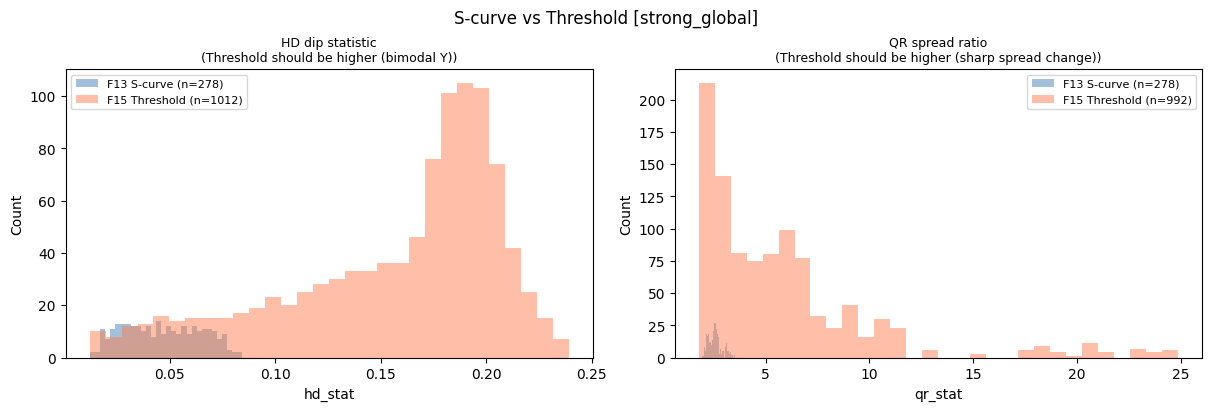


=== Statistic value summary: F13 vs F15 [strong_global] ===


,family_name,n,hd_dip_median,hd_dip_mean,qr_ratio_median,qr_ratio_mean
family_id,,,,,,
F13,S-curve positive,278,0.0456,0.0465,2.5458,2.5691
F15,Threshold positive,1012,0.1755,0.1565,4.6247,5.8358



=== S vs Threshold analysis [intermediate_global] ===
S/Threshold cases for F13/F15: 109
  F13 S-curve: 84
  F15 Threshold: 25


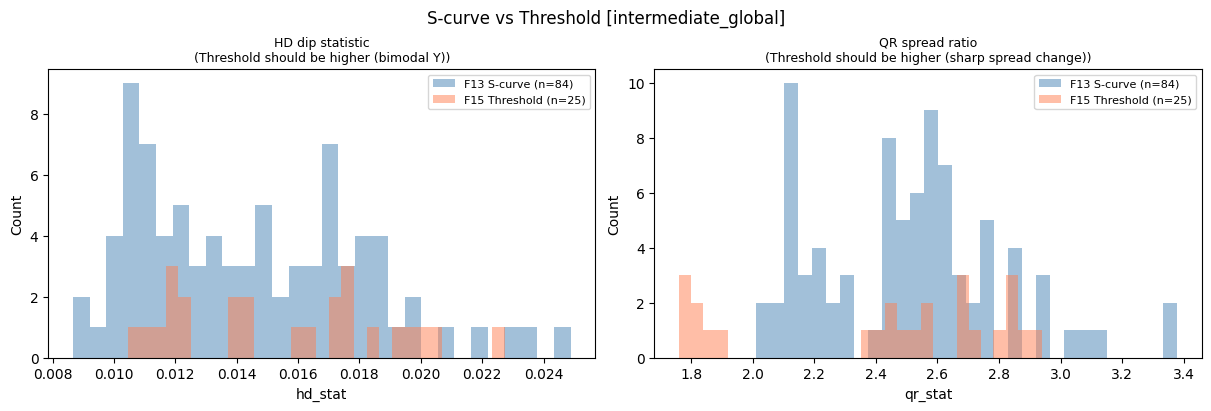


=== Statistic value summary: F13 vs F15 [intermediate_global] ===


,family_name,n,hd_dip_median,hd_dip_mean,qr_ratio_median,qr_ratio_mean
family_id,,,,,,
F13,S-curve positive,84,0.0140,0.0145,2.5227,2.5122
F15,Threshold positive,25,0.0161,0.0156,2.5133,2.4182


In [454]:
if RUN_METHOD_A and RUN_METHOD_B:
    import matplotlib.pyplot as plt

    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        klqrhd_df = klqrhd_dfs.get(_gate)
        if sizer_df is None or klqrhd_df is None:
            continue
        if len(sizer_df) == 0 or len(klqrhd_df) == 0:
            continue

        _st_merge = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
            klqrhd_df[['case_id', 'hd_stat', 'qr_stat', 'hd_sig', 'qr_sig']], on='case_id', how='inner'
        )

        _st_focus = _st_merge[
            (_st_merge['family_id'].isin(['F13', 'F15'])) &
            (_st_merge['sizer_label'].isin(['TP=0', 'Threshold']))
        ].copy()

        print(f'\n{"="*60}')
        print(f'=== S vs Threshold analysis [{_gate}] ===')
        print(f'{"="*60}')
        print(f'S/Threshold cases for F13/F15: {len(_st_focus)}')
        print(f'  F13 S-curve: {(_st_focus["family_id"]=="F13").sum()}')
        print(f'  F15 Threshold: {(_st_focus["family_id"]=="F15").sum()}')

        if len(_st_focus) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
            indicators = [
                ('hd_stat', 'HD dip statistic', 'Threshold should be higher (bimodal Y)'),
                ('qr_stat', 'QR spread ratio', 'Threshold should be higher (sharp spread change)'),
            ]
            for ax, (col, title, note) in zip(axes, indicators):
                for fid, color, label in [('F13', 'steelblue', 'F13 S-curve'), ('F15', 'coral', 'F15 Threshold')]:
                    vals = _st_focus.loc[_st_focus['family_id'] == fid, col].dropna()
                    ax.hist(vals, bins=30, alpha=0.5, color=color, label=f'{label} (n={len(vals)})')
                ax.set_title(f'{title}\n({note})', fontsize=9)
                ax.set_xlabel(col)
                ax.set_ylabel('Count')
                ax.legend(fontsize=8)
            fig.suptitle(f'S-curve vs Threshold [{_gate}]', fontsize=12)
            plt.show()

            print(f'\n=== Statistic value summary: F13 vs F15 [{_gate}] ===')
            _summary = _st_focus.groupby('family_id').agg(
                n=('case_id', 'size'),
                hd_dip_median=('hd_stat', 'median'),
                hd_dip_mean=('hd_stat', 'mean'),
                qr_ratio_median=('qr_stat', 'median'),
                qr_ratio_mean=('qr_stat', 'mean'),
            ).round(4)
            _summary.insert(0, 'family_name', _summary.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', '')))
            display(_summary)
        else:
            print('No S/Threshold cases for F13/F15.')

In [455]:
if RUN_METHOD_A and RUN_METHOD_B:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        klqrhd_df = klqrhd_dfs.get(_gate)
        if sizer_df is None or klqrhd_df is None:
            continue

        _st_merge = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
            klqrhd_df[['case_id', 'hd_stat', 'qr_stat', 'hd_sig', 'qr_sig']], on='case_id', how='inner'
        )
        _st_focus = _st_merge[
            (_st_merge['family_id'].isin(['F13', 'F15'])) &
            (_st_merge['sizer_label'].isin(['TP=0', 'Threshold']))
        ].copy()

        print(f'\n{"="*60}')
        print(f'=== S vs Threshold classification [{_gate}] ===')
        print(f'{"="*60}')

        if len(_st_focus) > 0:
            results = []
            for col, name, direction in [
                ('hd_stat', 'HD dip', 'high_is_threshold'),
                ('qr_stat', 'QR ratio', 'high_is_threshold'),
            ]:
                vals = _st_focus[col].dropna()
                if len(vals) == 0:
                    continue
                thresholds = np.percentile(vals, np.arange(10, 91, 5))
                best_thr_acc = 0
                best_thr = 0
                for thr in thresholds:
                    if direction == 'high_is_threshold':
                        pred = np.where(_st_focus[col] >= thr, 'Threshold', 'S-curve')
                    else:
                        pred = np.where(_st_focus[col] >= thr, 'S-curve', 'Threshold')
                    truth = _st_focus['family_id'].map({'F13': 'S-curve', 'F15': 'Threshold'})
                    acc = (pred == truth).mean()
                    if acc > best_thr_acc:
                        best_thr_acc = acc
                        best_thr = thr
                results.append({
                    'Indicator': name,
                    'Best threshold': f'{best_thr:.4f}',
                    'Accuracy': f'{best_thr_acc:.1%}',
                    'Direction': direction,
                })
            print(f'Best single-indicator classification:')
            display(pd.DataFrame(results))
        else:
            print('No data to evaluate.')


=== S vs Threshold classification [strong_global] ===
Best single-indicator classification:


,Indicator,Best threshold,Accuracy,Direction
0,HD dip,0.0788,90.6%,high_is_threshold
1,QR ratio,2.2980,73.4%,high_is_threshold



=== S vs Threshold classification [intermediate_global] ===
Best single-indicator classification:


,Indicator,Best threshold,Accuracy,Direction
0,HD dip,0.0194,74.3%,high_is_threshold
1,QR ratio,2.8228,70.6%,high_is_threshold


## Head-to-head comparison

Merge SiZer and KL/QR/HD results and compare accuracy per family.

In [456]:
if RUN_METHOD_A and RUN_METHOD_B:
    for _gate in MIC_ANALYSIS_GATES:
        sizer_df = sizer_dfs.get(_gate)
        klqrhd_df = klqrhd_dfs.get(_gate)
        if sizer_df is None or klqrhd_df is None:
            continue

        compare = sizer_df[['case_id', 'family_id', 'family_name', 'sizer_label']].merge(
            klqrhd_df[['case_id', 'klqrhd_label', 'hd_stat', 'qr_stat']], on='case_id', how='outer'
        )

        compare['expected_tp'] = compare['family_id'].map(EXPECTED_TP_LABEL)
        compare['tp_correct'] = compare['sizer_label'] == compare['expected_tp']

        compare['expected_klqrhd'] = compare['family_id'].map(EXPECTED_KLQRHD)
        compare['klqrhd_correct'] = compare['klqrhd_label'] == compare['expected_klqrhd']
        compare['klqrhd_merged'] = compare['klqrhd_label'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
        compare['expected_merged'] = compare['expected_klqrhd'].replace({'S-curve': 'S/Threshold', 'Threshold': 'S/Threshold'})
        compare['klqrhd_correct_merged'] = compare['klqrhd_merged'] == compare['expected_merged']

        print(f'\n{"="*60}')
        print(f'=== Comparison: Multiscale TP vs KL/QR/HD [{_gate}] ===')
        print(f'{"="*60}')

        rows = []
        for fid in sorted(compare['family_id'].unique()):
            sub = compare[compare['family_id'] == fid]
            fname = FAMILY_CATALOGUE.get(fid, {}).get('name', fid)
            n = len(sub)
            exp_tp = EXPECTED_TP_LABEL.get(fid)

            if exp_tp is not None:
                tc = int(sub['tp_correct'].sum())
                tp_acc = f'{tc}/{n} ({tc/n:.1%})'
            else:
                tp_acc = 'N/A'

            exp_kl = EXPECTED_KLQRHD.get(fid)
            if exp_kl is not None:
                kc = int(sub['klqrhd_correct'].sum())
                kcm = int(sub['klqrhd_correct_merged'].sum())
                kl_acc = f'{kc}/{n} ({kc/n:.1%})'
                kl_acc_m = f'{kcm}/{n} ({kcm/n:.1%})'
            else:
                kl_acc = 'N/A'
                kl_acc_m = 'N/A'

            rows.append({
                'Family': f'{fid} {fname}',
                'n': n,
                'Expected (TP)': exp_tp or 'N/A',
                'Multiscale TP': tp_acc,
                'KL/QR/HD (3-way)': kl_acc,
                'KL/QR/HD (S/T merged)': kl_acc_m,
            })

        _eval = compare[compare['expected_tp'].notna()]
        if len(_eval) > 0:
            n_t = len(_eval)
            tc_t = int(_eval['tp_correct'].sum())
            rows.append({
                'Family': 'Overall (with expected)',
                'n': n_t,
                'Expected (TP)': '',
                'Multiscale TP': f'{tc_t}/{n_t} ({tc_t/n_t:.1%})',
                'KL/QR/HD (3-way)': 'N/A',
                'KL/QR/HD (S/T merged)': 'N/A',
            })

        display(pd.DataFrame(rows).set_index('Family'))


=== Comparison: Multiscale TP vs KL/QR/HD [strong_global] ===


,n,Expected (TP),Multiscale TP,KL/QR/HD (3-way),KL/QR/HD (S/T merged)
Family,,,,,
F01 Linear positive,34,TP=0,34/34 (100.0%),N/A,N/A
F07 Saturation positive,55,TP=0,0/55 (0.0%),N/A,N/A
F13 S-curve positive,282,TP=0,278/282 (98.6%),12/282 (4.3%),268/282 (95.0%)
F15 Threshold positive,1112,TP=0,47/1112 (4.2%),1064/1112 (95.7%),1075/1112 (96.7%)
F18 Quadratic valley (U),916,TP=1,916/916 (100.0%),N/A,N/A
F21 Cubic,549,TP=2,549/549 (100.0%),68/549 (12.4%),68/549 (12.4%)
F22 Oscillation,987,TP≥3,987/987 (100.0%),N/A,N/A
F23 Two Lines,71,N/A,N/A,N/A,N/A
F25 Multi-regime threshold,10,TP≥3,0/10 (0.0%),N/A,N/A



=== Comparison: Multiscale TP vs KL/QR/HD [intermediate_global] ===


,n,Expected (TP),Multiscale TP,KL/QR/HD (3-way),KL/QR/HD (S/T merged)
Family,,,,,
F01 Linear positive,155,TP=0,155/155 (100.0%),N/A,N/A
F03 Power convex positive,78,TP=0,58/78 (74.4%),N/A,N/A
F05 Power concave positive,77,TP=0,77/77 (100.0%),N/A,N/A
F07 Saturation positive,582,TP=0,0/582 (0.0%),N/A,N/A
F13 S-curve positive,114,TP=0,84/114 (73.7%),60/114 (52.6%),63/114 (55.3%)
F15 Threshold positive,99,TP=0,25/99 (25.3%),3/99 (3.0%),84/99 (84.8%)
F18 Quadratic valley (U),173,TP=1,173/173 (100.0%),N/A,N/A
F21 Cubic,332,TP=2,332/332 (100.0%),0/332 (0.0%),0/332 (0.0%)
F22 Oscillation,153,TP≥3,153/153 (100.0%),N/A,N/A
